# Q1: Estimated need vs. food shelf activity

- **Part 1 (sections 1–7):** Do the two sets of numbers tell the same story?
- **Part 2 (sections 8–15):** Which food shelf metrics have stronger or weaker correlations with Feeding America's need estimates?
- **Part 3 (sections 16–25):** Which counties break the pattern?
- **Part 4 (sections 26–36):** What county characteristics might explain the mismatches? (incl. distance to the nearest food shelf, 28a)
- **Final Q1 synthesis (section 37)**

**MinneMUDAC 2026 · The Food Group**

## 1. Question / goal

> *"Do these two sets of numbers tell the same story for the three food shelf metrics (e.g. Visits, Pounds distributed, and Individuals served)?"*

| | Source | What it measures |
|---|---|---|
| **Need** | Feeding America *Map the Meal Gap* (MMG) | a **model estimate** of food-insecure people per county |
| **Activity** | The Food Group food shelf reports (cleaned `org_FSStats`) | recorded visits, pounds and individuals |

The units differ (people vs. trips vs. pounds), so we never subtract one from the other. "Same story" means they **move together**: the same counties rank high on both, and both rise or fall over time.

*Map the Meal Gap data: Feeding America, Map the Meal Gap 2025 and 2026 releases. Must be cited whenever used.*

## 2. Imports and paths

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

# Works whether the notebook is run from the repo root or from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "Data" / "processed"
print(PROCESSED)

# One consistent look for every chart. Colors: one fixed color per metric, used everywhere.
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "#8a8984",
    "axes.labelcolor": "#2b2b2b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "font.size": 10,
})
METRICS = ["visits", "pounds", "individuals"]
LABEL = {"visits": "Visits (household trips)", "pounds": "Pounds distributed", "individuals": "Individuals served"}
COLOR = {"visits": "#2a78d6", "pounds": "#eb6834", "individuals": "#1baf7a", "need": "#3d3d3a"}

C:\Users\eirfa\Documents\UW_Madison_Edu\MINNEMUDAC_2026\Data\processed


## 3. Load the data

We use the cleaned files in `Data/processed/` (see `Data/processed/README.md` and `docs/02_clean_foodshelf.md`). We read `fips` as text so codes like `27001` stay intact.

In [2]:
fs_month = pd.read_csv(PROCESSED / "foodshelf_county_month.csv", dtype={"fips": str}, parse_dates=["month"])
issues   = pd.read_csv(PROCESSED / "foodshelf_issues_log.csv")
mmg      = pd.read_csv(PROCESSED / "mmg_mn_county_2022_2024.csv", dtype={"fips": str})

for name, df in [("foodshelf_county_month", fs_month), ("foodshelf_issues_log", issues), ("mmg_mn_county_2022_2024", mmg)]:
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print("  columns:", list(df.columns), "\n")

foodshelf_county_month: 4,785 rows x 12 columns
  columns: ['fips', 'county', 'month', 'visits', 'pounds', 'individuals', 'adults', 'children', 'seniors', 'n_sites', 'n_sites_reported', 'n_sites_missing'] 

foodshelf_issues_log: 430 rows x 9 columns
  columns: ['site_id', 'year', 'month_num', 'county_original', 'visits', 'individuals', 'pounds', 'issue', 'action'] 

mmg_mn_county_2022_2024: 261 rows x 21 columns
  columns: ['fips', 'county', 'year', 'fi_rate', 'fi_persons', 'child_fi_rate', 'fi_children', 'fi_rate_black', 'fi_rate_hispanic', 'fi_rate_white_nh', 'snap_threshold', 'pct_fi_below_snap_threshold', 'pct_fi_above_snap_threshold', 'pct_fi_children_below_185fpl', 'pct_fi_children_above_185fpl', 'cost_per_meal', 'weekly_dollars_needed_per_fi', 'annual_food_budget_shortfall', 'rucc_2023', 'source_file', 'rural'] 



In [3]:
display(fs_month.head(3))
display(mmg.head(3))

,fips,county,month,visits,pounds,individuals,adults,children,seniors,n_sites,n_sites_reported,n_sites_missing
0,27001,Aitkin,2022-01-01,222.0,11249.0,547.0,238.0,114.0,195.0,6,6,0
1,27001,Aitkin,2022-02-01,222.0,11249.0,547.0,238.0,114.0,195.0,6,6,0
2,27001,Aitkin,2022-03-01,234.0,12729.0,562.0,224.0,126.0,212.0,5,5,0


,fips,county,year,fi_rate,fi_persons,child_fi_rate,fi_children,fi_rate_black,fi_rate_hispanic,fi_rate_white_nh,snap_threshold,pct_fi_below_snap_threshold,pct_fi_above_snap_threshold,pct_fi_children_below_185fpl,pct_fi_children_above_185fpl,cost_per_meal,weekly_dollars_needed_per_fi,annual_food_budget_shortfall,rucc_2023,source_file,rural
0,27001,Aitkin,2022,0.130,2060.0,0.199,510.0,NaN,NaN,0.10,2.0,0.754,0.246,0.76,0.24,4.37,27.07,1692000.0,8.0,MMG2025_2019-2023_Data_To_Share_v2.xlsx,True
1,27001,Aitkin,2023,0.137,2190.0,0.204,520.0,NaN,NaN,0.11,2.0,0.706,0.294,0.67,0.33,3.80,23.76,1579000.0,8.0,MMG2025_2019-2023_Data_To_Share_v2.xlsx,True
2,27001,Aitkin,2024,0.150,2420.0,0.220,550.0,NaN,NaN,0.11,2.0,0.740,0.260,0.68,0.32,3.86,24.15,1773000.0,8.0,MMG2026_2024_Data_To_Share.xlsx,True


We don't need `foodshelf_site_month.csv` here: the county-month file is built from it (sites summed, meal programs excluded).

### Population (denominator only)

For per-resident comparisons we take **only the `population` column** from the cleaned Census ACS file (`poverty_2022_2024_clean.csv`). No poverty rates are used until Part 4.

In [4]:
pop = (pd.read_csv(PROCESSED / "poverty_2022_2024_clean.csv", dtype={"county_geoid": str})
         .rename(columns={"county_geoid": "fips"})[["fips", "year", "population"]])
print(pop.shape)
pop.head()

(261, 3)


,fips,year,population
0,27001,2022,15627
1,27003,2022,360581
2,27005,2022,34515
3,27007,2022,44355
4,27009,2022,40545


## 4. Understand the variables

### What one row means

| File | One row = | Years |
|---|---|---|
| `foodshelf_county_month.csv` | one county × one month (all 87 counties, every month) | Jan 2022 – Jul 2026 |
| `mmg_mn_county_2022_2024.csv` | one county × one year | 2022, 2023, 2024 |

### Need measures (Feeding America)

| Column | Meaning | Use |
|---|---|---|
| `fi_persons` | estimated number of food-insecure people | compare with **total** activity |
| `fi_rate` | estimated share of residents who are food insecure | compare with activity **per resident** |

### Activity measures (The Food Group)

| Brief's name | Column | Unit | Comes from raw column |
|---|---|---|---|
| Visits | `visits` | household trips | `HouseholdsReg` |
| Pounds distributed | `pounds` | pounds of food | `PoundsReg` |
| Individuals served | `individuals` | people served (adults + children + seniors) | `IndividualsReg` |

Important: **`individuals` is not a count of unique people.** A person who visits every month is counted 12 times a year. So "individuals served" in a year can easily be larger than the number of food-insecure people, and that is not a contradiction.

In [5]:
# Quick check of years and coverage in each file
fs_month["year"] = fs_month["month"].dt.year
print("Food shelf months:", fs_month["month"].min().date(), "to", fs_month["month"].max().date())
print("Food shelf counties:", fs_month["fips"].nunique())
print(fs_month.groupby("year")["month"].nunique().rename("months per year").to_string(), "\n")
print("MMG years:", sorted(mmg["year"].unique()), "| counties:", mmg["fips"].nunique())
print(mmg.groupby("year")["source_file"].unique().to_string())

Food shelf months: 2022-01-01 to 2026-07-01
Food shelf counties: 87
year
2022    12
2023    12
2024    12
2025    12
2026     7 

MMG years: [2022, 2023, 2024] | counties: 87
year
2022    [MMG2025_2019-2023_Data_To_Share_v2.xlsx]
2023    [MMG2025_2019-2023_Data_To_Share_v2.xlsx]
2024            [MMG2026_2024_Data_To_Share.xlsx]


### Known warnings that matter for this analysis

From `Data/processed/README.md`, `docs/02_clean_foodshelf.md` and the issues log:

1. **"Visits" definition is ambiguous.** We follow the brief (Visits = household trips, `HouseholdsReg`). But The Food Group's own published "visits" match `IndividualsReg` instead. The team has asked the organizers. Here this matters less, because we analyze both metrics anyway.
2. **Blank ≠ zero.** A blank month means no site in that county reported, not that nobody came.
3. **Wilkin County has no food shelf in the data** (`n_sites = 0` every month). It cannot be compared and is kept visible, not dropped silently.
4. **Typos were removed** (e.g. Waseca, Jul 2023: 273,385 households) and set to missing; some large-but-plausible outliers were **kept and flagged**.
5. **MMG 2024 comes from a different release** (MMG2026) than 2022–2023 (MMG2025). Feeding America sometimes revises methods between releases, so small year-to-year jumps in MMG may partly reflect method changes. (The README warns specifically that cost-per-meal/budget columns are not comparable across years; we do not use those.)
6. **MMG county numbers are model estimates**, not counts, and they don't add up to the state total.

In [6]:
issues.groupby(["issue", "action"]).size().rename("rows").sort_values(ascending=False).to_frame()

,,rows
issue,action,
more households than individuals,"flagged, kept",145
"county blank, not in Organization.xlsx either",removed,116
duplicate site-month: two different values,summed into one row,56
value >10x site median (not a clear typo),"flagged, kept",43
invalid month number (0 or 15),removed,26
county blank in org_FSStats,filled from Organization.xlsx,16
duplicate site-month: exact copy,removed copy,11
visits typo: >10x site median and more households than individuals,visits set to missing,7
duplicate site-month: blank copy of a reported row,removed blank copy,5


## 5. Prepare comparable data

### 5a. Choose the years

MMG covers **2022, 2023, 2024**. Food shelf data covers 2022 through mid-2026. The only years where we have both are **2022–2024**, all with 12 full months of food shelf data. 2025 and 2026 are left out of this comparison.

### 5b. County × month → county × year

We **sum** the 12 months for each county-year. Along the way we count how complete each county-year's reporting is, so problems are visible rather than hidden:
- `months_reported`: months with any reported number (out of 12)
- `site_months` / `site_months_missing`: site-months that existed / that didn't send numbers

In [7]:
fs = fs_month[fs_month["year"].between(2022, 2024)].copy()

fs_year = (fs.groupby(["fips", "year"])
             .agg(county=("county", "first"),
                  visits=("visits", "sum"),
                  pounds=("pounds", "sum"),
                  individuals=("individuals", "sum"),
                  months_reported=("visits", lambda s: s.notna().sum()),
                  site_months=("n_sites", "sum"),
                  site_months_missing=("n_sites_missing", "sum"))
             .reset_index())

# pandas' sum() turns "all blank" into 0. A county with zero reported months must be MISSING, not zero.
no_data = fs_year["months_reported"] == 0
fs_year.loc[no_data, METRICS] = np.nan
fs_year["share_site_months_missing"] = fs_year["site_months_missing"] / fs_year["site_months"]

print(fs_year.shape)

(261, 10)


In [8]:
# County-years whose annual totals may be understated: missing months, or >10% of site-months unreported
# (Wilkin is excluded here: it has no food shelf at all, which is different from incomplete reporting)
has_sites = fs_year["months_reported"] > 0
fs_year.loc[has_sites & ((fs_year["months_reported"] < 12) | (fs_year["share_site_months_missing"] > 0.10)),
            ["county", "year", "months_reported", "site_months", "site_months_missing", "share_site_months_missing"]].round(2)

,county,year,months_reported,site_months,site_months_missing,share_site_months_missing
9,Beltrami,2022,12,34,5,0.15
10,Beltrami,2023,12,60,18,0.30
11,Beltrami,2024,12,59,12,0.20
15,Big Stone,2022,12,15,3,0.20
61,Douglas,2023,11,12,0,0.00
75,Grant,2022,9,23,14,0.61
224,Stevens,2024,9,12,3,0.25


A handful of county-years have incomplete reporting, so their annual totals are **too low**. We do **not** fill them in (that would invent data). Instead we add an `incomplete` flag and, in Part 2 (section 14), check whether removing them changes the conclusions.

### 5c. Join with Map the Meal Gap and population

Join on `fips` + `year` (never on county names). We use an outer join with an indicator so nothing can be dropped silently.

In [9]:
df = mmg[["fips", "county", "year", "fi_rate", "fi_persons", "rural"]].merge(
    fs_year.drop(columns="county"), on=["fips", "year"], how="outer", indicator="merge_fs")
df = df.merge(pop, on=["fips", "year"], how="outer", indicator="merge_pop")

print("MMG <-> food shelf join:\n", df["merge_fs"].value_counts().to_string(), "\n")
print("... <-> population join:\n", df["merge_pop"].value_counts().to_string(), "\n")
print("Rows:", len(df), "| counties:", df["fips"].nunique(), "| years:", sorted(df["year"].unique()))
print("Rows per year:", df.groupby("year").size().to_dict())

MMG <-> food shelf join:
 merge_fs
both          261
left_only       0
right_only      0 

... <-> population join:
 merge_pop
both          261
left_only       0
right_only      0 

Rows: 261 | counties: 87 | years: [2022, 2023, 2024]
Rows per year: {2022: 87, 2023: 87, 2024: 87}


In [10]:
# Unmatched rows (should be none) and missing values
print("Unmatched rows:", int((df["merge_fs"] != "both").sum() + (df["merge_pop"] != "both").sum()))
df[["fi_rate", "fi_persons", "population"] + METRICS].isna().sum().rename("missing values").to_frame()
print("County-years without activity:", df.loc[df["visits"].isna(), ["county", "year"]].values.tolist())

Unmatched rows: 0
County-years without activity: [['Wilkin', 2022], ['Wilkin', 2023], ['Wilkin', 2024]]


All 261 county-years match on both joins. The only missing activity values are **Wilkin County** (no food shelf), which we keep in the table but which drops out of any comparison that needs activity.

**Sanity check on population.** MMG reports both `fi_persons` and `fi_rate`, so it implies its own population (`fi_persons / fi_rate`). It should be close to the Census population.

In [11]:
implied = df["fi_persons"] / df["fi_rate"]
print("MMG-implied population / Census population:")
print((implied / df["population"]).describe().round(3).to_string())

MMG-implied population / Census population:
count    261.000
mean       1.025
std        0.018
min        1.001
25%        1.014
50%        1.020
75%        1.028
max        1.128


They agree within a few percent, so the Census population is a reasonable denominator.

### 5d. Derived columns

- **Activity per 1,000 residents** = activity ÷ population × 1,000, compared with `fi_rate`.
- **`incomplete` flag** = fewer than 12 reported months **or** more than 10% of site-months missing.

In [12]:
for m in METRICS:
    df[f"{m}_per_1k"] = df[m] / df["population"] * 1000

df["incomplete"] = (df["months_reported"] < 12) | (df["share_site_months_missing"] > 0.10)
df = df.drop(columns=["merge_fs", "merge_pop"])

# The comparison set: every county-year that has food shelf activity
comp = df.dropna(subset=["visits"]).copy()
print("Comparison county-years:", len(comp), "| per year:", comp.groupby("year").size().to_dict())
print("Flagged incomplete:", int(comp["incomplete"].sum()))
comp[["county", "year", "fi_rate", "fi_persons", "population", "visits", "visits_per_1k"]].head()

Comparison county-years: 258 | per year: {2022: 86, 2023: 86, 2024: 86}
Flagged incomplete: 7


,county,year,fi_rate,fi_persons,population,visits,visits_per_1k
0,Aitkin,2022,0.130,2060.0,15627,3403.0,217.764126
1,Aitkin,2023,0.137,2190.0,15687,4501.0,286.925480
2,Aitkin,2024,0.150,2420.0,15824,3971.0,250.947927
3,Anoka,2022,0.072,26300.0,360581,160898.0,446.218741
4,Anoka,2023,0.085,31330.0,363694,203002.0,558.167031


## 6. Exploratory comparison

We look at three angles: **over time** (statewide), **by size** (totals), and **by intensity** (per resident). We use **Spearman's ρ** (rank correlation, robust to huge counties like Hennepin), computed **separately per year**.

### 6.1 Statewide trend: does everything go up together?

All counties summed per year and indexed to 2022 = 100, so trips, pounds and people share one axis. (MMG county numbers don't sum exactly to the state total, so this is approximate.)

In [13]:
state = comp.groupby("year")[["fi_persons"] + METRICS].sum()
state_idx = state / state.loc[2022] * 100
display(state.style.format("{:,.0f}"))
display(state_idx.round(1))

,fi_persons,visits,pounds,individuals
year,,,,
2022,"508,730","1,963,236","118,672,911","5,626,130"
2023,"580,480","2,482,146","139,985,146","7,625,430"
2024,"635,800","2,862,391","155,558,493","8,994,350"


,fi_persons,visits,pounds,individuals
year,,,,
2022,100.0,100.0,100.0,100.0
2023,114.1,126.4,118.0,135.5
2024,125.0,145.8,131.1,159.9


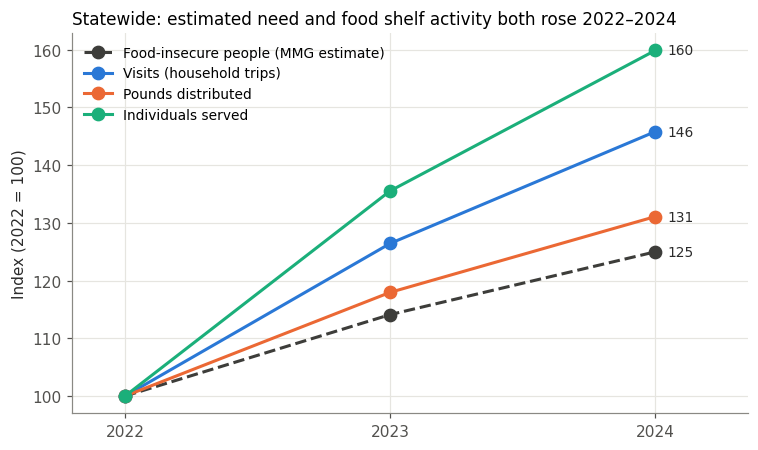

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.2))
years = state_idx.index
ax.plot(years, state_idx["fi_persons"], color=COLOR["need"], lw=2, ls="--", marker="o", ms=8,
        label="Food-insecure people (MMG estimate)")
for m in METRICS:
    ax.plot(years, state_idx[m], color=COLOR[m], lw=2, marker="o", ms=8, label=LABEL[m])
for col, color in [("fi_persons", COLOR["need"])] + [(m, COLOR[m]) for m in METRICS]:
    ax.annotate(f"{state_idx.loc[2024, col]:.0f}", (2024, state_idx.loc[2024, col]),
                xytext=(8, 0), textcoords="offset points", va="center", color="#2b2b2b", fontsize=9)
ax.set_xticks(years)
ax.set_xlim(2021.8, 2024.35)
ax.set_ylabel("Index (2022 = 100)")
ax.set_title("Statewide: estimated need and food shelf activity both rose 2022–2024", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

Statewide, **both rose**: estimated food insecurity +25% from 2022 to 2024, while visits rose +46%, pounds +31% and individuals +60%. The *direction* agrees; the *size* of the change does not.

### 6.2 Across counties, by size: totals vs. food-insecure people

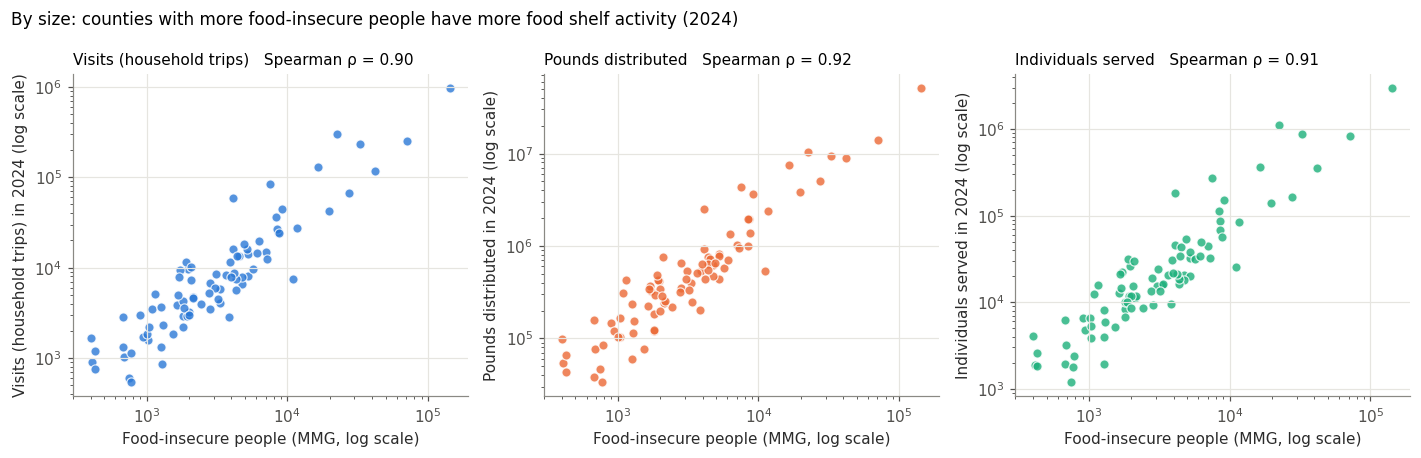

In [15]:
YEAR = 2024
d = comp[comp["year"] == YEAR]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, m in zip(axes, METRICS):
    rho = d["fi_persons"].corr(d[m], method="spearman")
    ax.scatter(d["fi_persons"], d[m], s=36, color=COLOR[m], alpha=0.8, edgecolor="white", linewidth=0.8)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Food-insecure people (MMG, log scale)")
    ax.set_ylabel(f"{LABEL[m]} in {YEAR} (log scale)")
    ax.set_title(f"{LABEL[m]}   Spearman ρ = {rho:.2f}", loc="left", fontsize=10)
fig.suptitle(f"By size: counties with more food-insecure people have more food shelf activity ({YEAR})",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

A strong relationship. But there is a catch: **big counties have more of everything**. Food-insecure people, food shelf visits, and simply residents all scale with population. So a high correlation here might only mean "big counties are big".

A quick test: how well does **plain population** (with no information about food insecurity) rank counties by activity, compared with MMG's food-insecure count?

In [16]:
rows = []
for year, g in comp.groupby("year"):
    for m in METRICS:
        rows.append({"year": year, "metric": m,
                     "rho with fi_persons (MMG)": g["fi_persons"].corr(g[m], method="spearman"),
                     "rho with population only": g["population"].corr(g[m], method="spearman")})
size_tbl = pd.DataFrame(rows).set_index(["year", "metric"]).round(2)
for year, g in comp.groupby("year"):
    print(f"{year}: Spearman rho between fi_persons and population = {g['fi_persons'].corr(g['population'], method='spearman'):.3f}")
size_tbl

2022: Spearman rho between fi_persons and population = 0.991
2023: Spearman rho between fi_persons and population = 0.994
2024: Spearman rho between fi_persons and population = 0.991


rho with fi_persons (MMG)  rho with population only
year metric                                                          
2022 visits                            0.89                      0.88
     pounds                            0.92                      0.91
     individuals                       0.90                      0.89
2023 visits                            0.89                      0.89
     pounds                            0.91                      0.91
     individuals                       0.89                      0.89
2024 visits                            0.90                      0.91
     pounds                            0.92                      0.92
     individuals                       0.91                      0.91

`fi_persons` and population rank counties almost identically (ρ ≈ 0.99), and **population alone ranks activity just as well as MMG does**. So the "by size" agreement mostly reflects **county size**, not need.

### 6.3 Across counties, by intensity: food insecurity rate vs. activity per resident

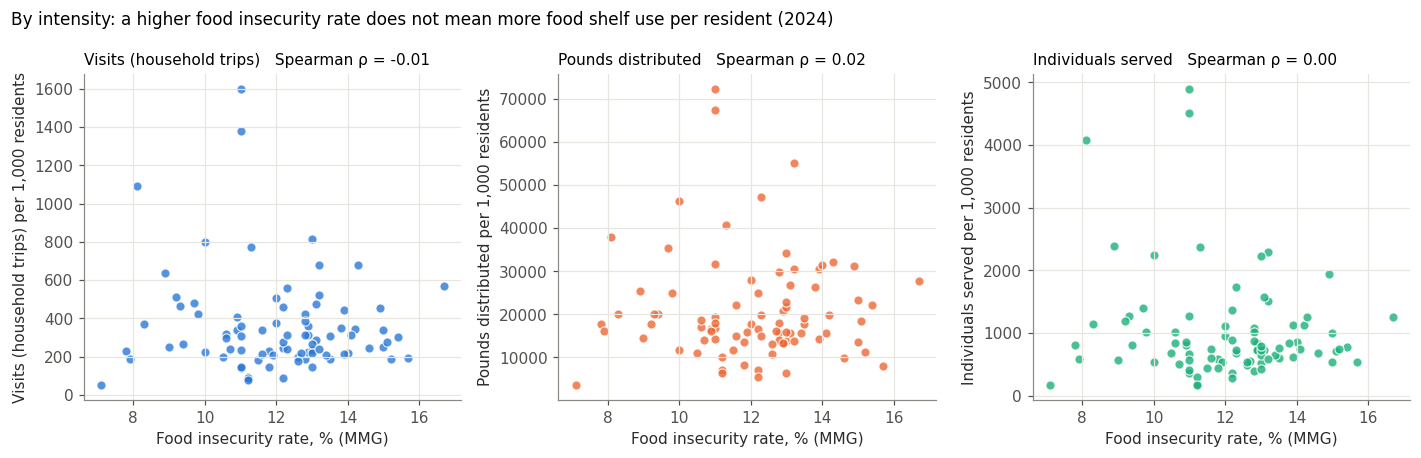

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, m in zip(axes, METRICS):
    col = f"{m}_per_1k"
    rho = d["fi_rate"].corr(d[col], method="spearman")
    ax.scatter(d["fi_rate"] * 100, d[col], s=36, color=COLOR[m], alpha=0.8, edgecolor="white", linewidth=0.8)
    ax.set_xlabel("Food insecurity rate, % (MMG)")
    ax.set_ylabel(f"{LABEL[m]} per 1,000 residents")
    ax.set_title(f"{LABEL[m]}   Spearman ρ = {rho:.2f}", loc="left", fontsize=10)
fig.suptitle(f"By intensity: a higher food insecurity rate does not mean more food shelf use per resident ({YEAR})",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

Once size is removed, the clouds are **flat**: counties with a higher food insecurity rate do not have noticeably more food shelf activity per resident (ρ ≈ 0 in 2024). Part 2 quantifies this year by year.

### 6.4 Do the three food shelf metrics agree with each other?

In [18]:
per1k = [f"{m}_per_1k" for m in METRICS]
inter = comp.groupby("year")[per1k].corr(method="spearman").round(2)
inter

visits_per_1k  pounds_per_1k  individuals_per_1k
year                                                                     
2022 visits_per_1k                1.00           0.79                0.91
     pounds_per_1k                0.79           1.00                0.84
     individuals_per_1k           0.91           0.84                1.00
2023 visits_per_1k                1.00           0.85                0.96
     pounds_per_1k                0.85           1.00                0.87
     individuals_per_1k           0.96           0.87                1.00
2024 visits_per_1k                1.00           0.79                0.92
     pounds_per_1k                0.79           1.00                0.85
     individuals_per_1k           0.92           0.85                1.00

Per resident, the three metrics agree closely (ρ ≈ 0.79–0.96): a county busy on visits is usually busy on individuals and pounds too. Pounds agrees a little less, since food per visit varies between food shelves. So the three metrics tell **one shared story**, and it is that story that differs from MMG's.

## 7. Part 1 findings

**Short answer: partly.**

- **By size: yes.** Counties with more estimated food-insecure people have more visits, pounds and individuals (ρ ≈ 0.9). But population alone does just as well, so this is mostly a size effect.
- **Over time: same direction, different size.** Need +25% vs. visits +46%, pounds +31%, individuals +60% (2022 → 2024).
- **By intensity: no.** A higher food insecurity *rate* does not go with more food shelf use *per resident*.
- **The three metrics agree with each other**, and all relate to MMG the same way. This holds whether "Visits" means households (brief's definition) or individuals (TFG's published counts).

**Caveats:** 2022–2024 only; `individuals` counts repeat visits; Wilkin has no food shelf; activity is recorded where the food shelf is, not where clients live; MMG is a model estimate and its 2024 values come from a newer release.

---

# Part 2: Which metrics have stronger or weaker correlations with Feeding America's need estimates?

We reuse `comp` from section 5 (86 counties × 3 years). No new data is loaded.

## 8. What exactly are we correlating?

### 8a. Which Feeding America measure?

`fi_persons` (number food insecure) for **totals**, and `fi_rate` (share food insecure) for **per-resident** comparisons. Other MMG columns describe sub-groups (children), *who* is food insecure (SNAP eligibility), or aren't comparable across years (cost per meal).

### 8b. Totals, rates, or both?

| Level | Need | Activity | Role |
|---|---|---|---|
| **A. Totals** | `fi_persons` | annual totals | context: mostly county size (section 6.2) |
| **B. Per resident** | `fi_rate` | activity per 1,000 residents | **main comparison** |

### 8c. Which population denominator?

ACS `population` (section 3), matched 261/261 rows by FIPS (section 5c). We don't use MMG's implied population (`fi_persons / fi_rate`), because it is derived from the need estimate and would put MMG on both sides of the comparison. ACS values are 5-year estimates, which is fine for a slowly changing denominator.

### 8d. Pearson and Spearman: why both

- **Pearson's r:** do the points fall on a straight line? It uses actual values, so a few extreme counties can pull it a lot.
- **Spearman's ρ:** do counties keep the same ranking? It uses ranks only, so one extreme county can't dominate.

If they agree, the result is solid. If not, a few counties are driving Pearson (checked in section 13). Correlations are computed **per year**, not pooled, so each county counts once.

## 9. Validation before correlating

Checks on the exact rows and columns that go into the correlations.

In [19]:
used_cols = ["fi_persons", "fi_rate", "population"] + METRICS + [f"{m}_per_1k" for m in METRICS]

print("Years:", sorted(comp["year"].unique()))
print("Counties per year:", comp.groupby("year")["fips"].nunique().to_dict())
print("Duplicate county-year rows:", int(comp.duplicated(["fips", "year"]).sum()))
print("Counties in merged table but not in the comparison:",
      sorted(set(df["county"]) - set(comp["county"])))
print("\nMissing values in the columns we correlate:")
print(comp[used_cols].isna().sum().to_string())
print("\nCounty-years with zero recorded activity:", int((comp[METRICS] == 0).any(axis=1).sum()))

Years: [2022, 2023, 2024]
Counties per year: {2022: 86, 2023: 86, 2024: 86}
Duplicate county-year rows: 0
Counties in merged table but not in the comparison: ['Wilkin']

Missing values in the columns we correlate:
fi_persons            0
fi_rate               0
population            0
visits                0
pounds                0
individuals           0
visits_per_1k         0
pounds_per_1k         0
individuals_per_1k    0

County-years with zero recorded activity: 0


3 years × 86 counties, no duplicates, no missing values. Wilkin (no food shelf) is the only county left out. The 7 incomplete county-years (section 5b) stay in, and section 14 re-runs without them.

## 10. Correlations, year by year

One function computes Pearson and Spearman (with p-values) for each level × year × metric.

In [20]:
from scipy import stats

# level name -> (need column, activity column pattern)
LEVELS = {
    "Totals":       ("fi_persons", "{m}"),
    "Per resident": ("fi_rate",    "{m}_per_1k"),
}
NICE = {"visits": "Visits", "pounds": "Pounds", "individuals": "Individuals"}


def correlate(data):
    rows = []
    for year, g in data.groupby("year"):
        for level, (need_col, pattern) in LEVELS.items():
            for m in METRICS:
                act_col = pattern.format(m=m)
                pearson_r, pearson_p = stats.pearsonr(g[need_col], g[act_col])
                spearman_r, spearman_p = stats.spearmanr(g[need_col], g[act_col])
                rows.append({"level": level, "year": year, "metric": m, "n": len(g),
                             "pearson": pearson_r, "pearson_p": pearson_p,
                             "spearman": spearman_r, "spearman_p": spearman_p})
    return pd.DataFrame(rows)


def corr_table(corr_long, level):
    # Wide table: rows = method x year, columns = metrics, plus which metric is highest in that row
    t = (corr_long[corr_long["level"] == level]
         .melt(id_vars=["year", "metric"], value_vars=["pearson", "spearman"], var_name="method", value_name="r")
         .pivot_table(index=["method", "year"], columns="metric", values="r")[METRICS])
    t["highest"] = t[METRICS].idxmax(axis=1)
    t["lowest"] = t[METRICS].idxmin(axis=1)
    return t.round(2)


corr = correlate(comp)

## 11. Results at a glance

Each cell is one correlation between MMG need and one food shelf metric. Blue = positive, red = negative, white = zero.

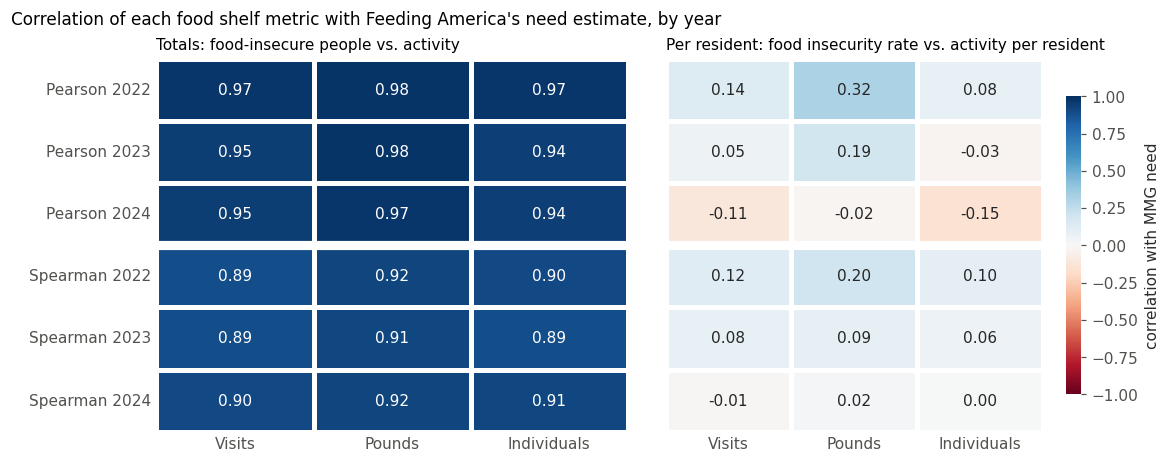

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), gridspec_kw={"wspace": 0.08})
for ax, level in zip(axes, ["Totals", "Per resident"]):
    t = corr_table(corr, level)[METRICS]
    t.index = [f"{method.capitalize()} {year}" for method, year in t.index]
    t.columns = [NICE[m] for m in t.columns]
    sns.heatmap(t, annot=True, fmt=".2f", cmap="RdBu", vmin=-1, vmax=1, center=0,
                cbar=(level == "Per resident"), cbar_kws={"label": "correlation with MMG need", "shrink": 0.8},
                linewidths=2, linecolor="white", ax=ax, annot_kws={"fontsize": 10},
                yticklabels=(level == "Totals"))
    ax.axhline(3, color="white", lw=6)  # separate Pearson rows from Spearman rows
    ax.grid(False)
    ax.tick_params(length=0)
    need = "food-insecure people" if level == "Totals" else "food insecurity rate"
    ax.set_title(f"{level}: {need} vs. activity" + ("" if level == "Totals" else " per resident"),
                 loc="left", fontsize=10)
fig.suptitle("Correlation of each food shelf metric with Feeding America's need estimate, by year",
             x=0.01, ha="left", fontsize=11)
plt.show()

- **Totals (left):** strong and positive for every metric (Pearson ≈ 0.94–0.98, Spearman ≈ 0.89–0.92). This mostly reflects county size.
- **Per resident (right):** weak for every metric (−0.15 to +0.32), fading to about zero by 2024.
- **Pounds is the highest in every row; Individuals is usually the lowest**, with Visits close behind. The gaps between metrics are much smaller than the gap between the two panels.

p-values for the per-resident correlations (how surprising each value would be if there were no real relationship):

In [22]:
# p-values for the per-resident correlations: how surprising would r be if there were truly no relationship?
(corr[corr["level"] == "Per resident"]
 .pivot_table(index="year", columns="metric", values=["pearson_p", "spearman_p"])
 .reindex(columns=METRICS, level=1)
 .round(3))

pearson_p                    spearman_p                   
metric    visits pounds individuals     visits pounds individuals
year                                                             
2022       0.202  0.003       0.488      0.271  0.064       0.338
2023       0.625  0.072       0.752      0.479  0.401       0.576
2024       0.330  0.821       0.180      0.912  0.887       0.983


Only **Pounds 2022 (Pearson r ≈ 0.32, p ≈ 0.003)** stands out, and its Spearman value is smaller (≈ 0.20). That hints that a few counties are pulling Pearson up (section 13).

## 12. Is the "strongest" metric clearly stronger?

**Bootstrap:** resample the 86 counties with replacement 2,000 times, recompute Spearman for all three metrics on the same resampled counties, and look at the middle 95%. If the interval for a *difference* between metrics includes 0, we can't say one metric is stronger.


In [23]:
rng = np.random.default_rng(2026)
N_BOOT = 2000
PAIRS = [("pounds", "visits"), ("pounds", "individuals"), ("visits", "individuals")]

ci_rows, diff_rows = [], []
for level, (need_col, pattern) in LEVELS.items():
    act_cols = [pattern.format(m=m) for m in METRICS]
    for year, g in comp.groupby("year"):
        data = g[[need_col] + act_cols].reset_index(drop=True)
        observed = pd.Series(data.corr(method="spearman").loc[need_col, act_cols].to_numpy(), index=METRICS)
        n = len(data)
        boot = []
        for _ in range(N_BOOT):
            sample = data.iloc[rng.integers(0, n, n)]
            boot.append(sample.corr(method="spearman").loc[need_col, act_cols].to_numpy())
        boot = pd.DataFrame(boot, columns=METRICS)

        for m in METRICS:
            ci_rows.append({"level": level, "year": year, "metric": m, "spearman": observed[m],
                            "ci_low": boot[m].quantile(0.025), "ci_high": boot[m].quantile(0.975)})
        for a, b in PAIRS:
            diff = boot[a] - boot[b]
            diff_rows.append({"level": level, "year": year, "comparison": f"{NICE[a]} − {NICE[b]}",
                              "observed difference": observed[a] - observed[b],
                              "95% low": diff.quantile(0.025), "95% high": diff.quantile(0.975),
                              "share of resamples > 0": (diff > 0).mean()})

boot_ci = pd.DataFrame(ci_rows)
boot_diff = pd.DataFrame(diff_rows)

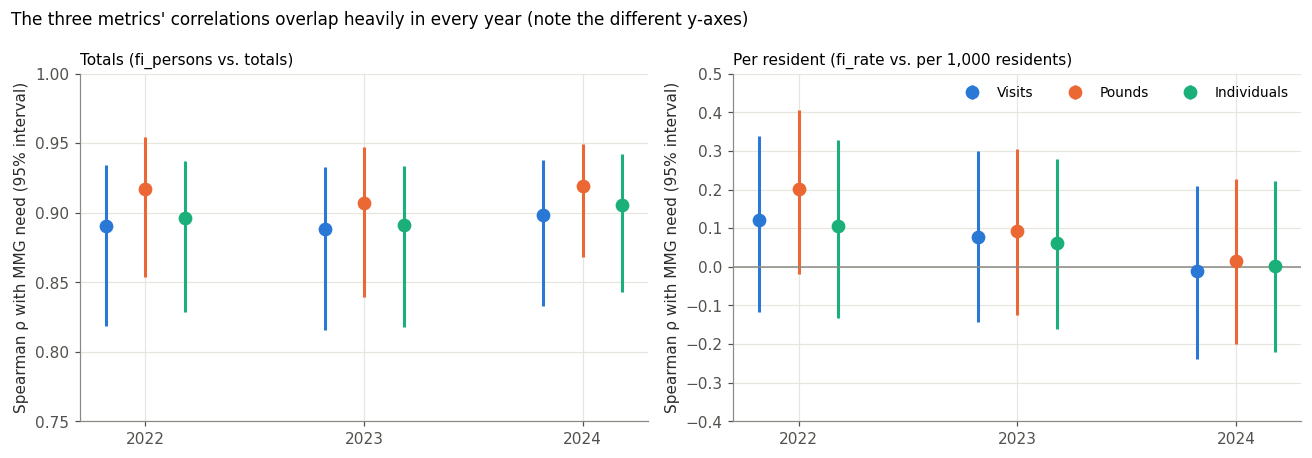

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
offsets = {"visits": -0.18, "pounds": 0, "individuals": 0.18}
for ax, level in zip(axes, ["Totals", "Per resident"]):
    sub = boot_ci[boot_ci["level"] == level]
    for m in METRICS:
        s = sub[sub["metric"] == m]
        x = s["year"] + offsets[m]
        ax.errorbar(x, s["spearman"], yerr=[s["spearman"] - s["ci_low"], s["ci_high"] - s["spearman"]],
                    fmt="o", ms=8, color=COLOR[m], ecolor=COLOR[m], elinewidth=2, capsize=0, label=NICE[m])
    ax.axhline(0, color="#8a8984", lw=1)
    ax.set_xticks([2022, 2023, 2024])
    ax.set_ylabel("Spearman ρ with MMG need (95% interval)")
    need = "fi_persons vs. totals" if level == "Totals" else "fi_rate vs. per 1,000 residents"
    ax.set_title(f"{level} ({need})", loc="left", fontsize=10)
axes[0].set_ylim(0.75, 1.0)
axes[1].set_ylim(-0.4, 0.5)
axes[1].legend(frameon=False, ncol=3, loc="upper right", fontsize=9)
fig.suptitle("The three metrics' correlations overlap heavily in every year (note the different y-axes)",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

In [25]:
boot_diff.round(2)

,level,year,comparison,observed difference,95% low,95% high,share of resamples > 0
0,Totals,2022,Pounds − Visits,0.03,-0.00,0.06,0.97
1,Totals,2022,Pounds − Individuals,0.02,-0.01,0.05,0.94
2,Totals,2022,Visits − Individuals,-0.01,-0.02,0.01,0.26
3,Totals,2023,Pounds − Visits,0.02,-0.01,0.05,0.91
4,Totals,2023,Pounds − Individuals,0.02,-0.01,0.05,0.91
5,Totals,2023,Visits − Individuals,-0.00,-0.03,0.02,0.40
6,Totals,2024,Pounds − Visits,0.02,-0.01,0.05,0.94
7,Totals,2024,Pounds − Individuals,0.01,-0.01,0.05,0.83
8,Totals,2024,Visits − Individuals,-0.01,-0.03,0.02,0.25
9,Per resident,2022,Pounds − Visits,0.08,-0.03,0.20,0.92


*"share of resamples > 0"* near 1.0 means the first metric was larger in almost every resample; near 0.5 is a coin flip.

- **Totals:** Pounds is ahead in 83–97% of resamples, but by only ~0.01–0.03.
- **Per resident:** every interval includes zero. Pounds is clearly ahead only in **2022** (92–96%); in 2023–2024 it's 57–70%.
- **Visits vs. Individuals** are never clearly separated.

So "Pounds is strongest" is **consistent but small**.

## 13. Are a few counties driving the correlations?

**Leave-one-out:** drop each county in turn and recompute. Influential counties are **named and kept**, not removed.

In [26]:
loo_rows = []
for level, (need_col, pattern) in LEVELS.items():
    for year, g in comp.groupby("year"):
        for m in METRICS:
            act_col = pattern.format(m=m)
            full_p = g[need_col].corr(g[act_col])
            full_s = g[need_col].corr(g[act_col], method="spearman")
            loo_p = pd.Series({i: g.drop(i)[need_col].corr(g.drop(i)[act_col]) for i in g.index})
            loo_s = pd.Series({i: g.drop(i)[need_col].corr(g.drop(i)[act_col], method="spearman") for i in g.index})
            most = (loo_p - full_p).abs().idxmax()
            loo_rows.append({"level": level, "year": year, "metric": m,
                             "pearson (all)": full_p,
                             "pearson range when 1 county removed": f"{loo_p.min():.2f} to {loo_p.max():.2f}",
                             "most influential county": g.loc[most, "county"],
                             "pearson without it": loo_p[most],
                             "spearman (all)": full_s,
                             "spearman range when 1 county removed": f"{loo_s.min():.2f} to {loo_s.max():.2f}"})
loo = pd.DataFrame(loo_rows)
loo.round(2)

,level,year,metric,pearson (all),pearson range when 1 county removed,most influential county,pearson without it,spearman (all),spearman range when 1 county removed
0,Totals,2022,visits,0.97,0.93 to 0.98,Hennepin,0.93,0.89,0.89 to 0.90
1,Totals,2022,pounds,0.98,0.95 to 0.98,Hennepin,0.95,0.92,0.91 to 0.93
2,Totals,2022,individuals,0.97,0.91 to 0.98,Hennepin,0.91,0.90,0.89 to 0.91
3,Totals,2023,visits,0.95,0.84 to 0.97,Hennepin,0.84,0.89,0.88 to 0.90
4,Totals,2023,pounds,0.98,0.94 to 0.98,Hennepin,0.94,0.91,0.90 to 0.92
5,Totals,2023,individuals,0.94,0.79 to 0.97,Hennepin,0.79,0.89,0.89 to 0.90
6,Totals,2024,visits,0.95,0.82 to 0.96,Hennepin,0.82,0.90,0.89 to 0.91
7,Totals,2024,pounds,0.97,0.92 to 0.98,Hennepin,0.92,0.92,0.92 to 0.93
8,Totals,2024,individuals,0.94,0.78 to 0.96,Hennepin,0.78,0.91,0.90 to 0.91
9,Per resident,2022,visits,0.14,-0.00 to 0.22,Mahnomen,-0.00,0.12,0.09 to 0.16


- **Totals:** **Hennepin** pulls Pearson up. Without it, Visits and Individuals drop to ≈ 0.8 (2024) while Pounds stays ≥ 0.92. Spearman barely moves.
- **Per resident:** **Mahnomen** (highest food insecurity rate in the state) is the most influential county in 2022–2023. **Pounds 2022 falls from 0.32 to 0.12 without it**, so the one significant result in section 11 rests on a single county. Spearman moves at most ±0.04, and Pounds stays highest.

## 14. Does incomplete reporting change the answer?

Re-run section 10 **without** the 7 county-years flagged incomplete.

In [27]:
corr_complete = correlate(comp[~comp["incomplete"]])
compare = (corr[["level", "year", "metric", "spearman", "pearson"]]
           .merge(corr_complete[["level", "year", "metric", "n", "spearman", "pearson"]],
                  on=["level", "year", "metric"], suffixes=(" (all)", " (complete only)")))
compare["max change"] = np.maximum((compare["spearman (all)"] - compare["spearman (complete only)"]).abs(),
                                   (compare["pearson (all)"] - compare["pearson (complete only)"]).abs())
print("Largest change in any correlation:", round(compare["max change"].max(), 3))
print("\nHighest / lowest metric per row, complete-reporting counties only:")
pd.concat({"Totals": corr_table(corr_complete, "Totals")[["highest", "lowest"]],
           "Per resident": corr_table(corr_complete, "Per resident")[["highest", "lowest"]]}, axis=1)

Largest change in any correlation: 0.027

Highest / lowest metric per row, complete-reporting counties only:


Totals              Per resident             
metric        highest       lowest      highest       lowest
method   year                                               
pearson  2022  pounds  individuals       pounds  individuals
         2023  pounds  individuals       pounds  individuals
         2024  pounds  individuals       pounds  individuals
spearman 2022  pounds       visits       pounds  individuals
         2023  pounds       visits       pounds  individuals
         2024  pounds       visits       pounds       visits

No correlation changes by more than 0.03, and the ordering of metrics is the same. Missing reports are not behind these results.

## 15. Part 2 summary

**Pounds distributed** was consistently the most strongly associated with Feeding America's need estimates, and **Individuals served** usually the weakest (Visits nearly tied with it). The differences are **small**.

| | Visits | Pounds | Individuals |
|---|---|---|---|
| **Totals**, Spearman 2022 / 2023 / 2024 | 0.89 / 0.89 / 0.90 | **0.92 / 0.91 / 0.92** | 0.90 / 0.89 / 0.91 |
| **Per resident**, Spearman | 0.12 / 0.08 / −0.01 | **0.20 / 0.09 / 0.02** | 0.10 / 0.06 / 0.00 |
| **Per resident**, Pearson | 0.14 / 0.05 / −0.11 | **0.32 / 0.19 / −0.02** | 0.08 / −0.03 / −0.15 |

- **Totals:** strong for all three (≈ 0.9), mostly county size.
- **Per resident:** weak for all three and fading to ≈ 0 by 2024.
- **Consistent across years:** the ordering held every year; bootstrap intervals overlap heavily.
- **Caveats:** associations, not causes. Hennepin (totals) and Mahnomen (per resident) are influential. Results hold under either "Visits" definition and without incomplete county-years.

---

# Part 3: Which counties break the pattern?

> Which counties have food shelf activity that is unusually **high** or **low** compared with what their estimated need suggests?

Counties are selected using **need and activity only** (plus reporting quality). Poverty, SNAP, distance and other characteristics are kept for Part 4, so the explanations are tested on counties that weren't chosen with them in mind.

## 16. Defining a "mismatch"

**Expected activity (Method A):** a log-scale regression of activity on the number of food-insecure people, fitted separately for each year and metric. It answers: *what do counties with a similar number of food-insecure people typically record?* Two alternatives are kept as robustness checks (17b):
- **B:** log(activity per resident) vs. food insecurity rate. Part 2 showed the rate barely predicts activity, so "expected" ends up nearly flat.
- **C:** the same activity per food-insecure person as the state median. This assumes strict proportionality, so big counties look "high".

**Gap** = log2(observed ÷ expected): 0 = as expected, **+1 = 2×**, **−1 = half**.

| Rule | Definition |
|---|---|
| **Flag** | gap ≥ +1 or ≤ −1 (at least 2×, or at most ½, of expected) |
| **Persistent** | flagged in the same direction in **≥ 2 of 3 years**, never in the opposite direction |
| **One-year** | flagged in exactly 1 year |
| **Reporting concern** | a "low" flag in an incomplete county-year (or with a removed visits typo), or a "high" flag where ≥ 20% of activity comes from rows flagged as spikes or duplicates. Kept and shown, but not counted towards persistence. |

## 17. Expected activity and gaps (Method A)

We start from `comp` (86 counties × 3 years; Wilkin has no food shelf and is handled separately at the end). For each year and metric we fit a straight line on the log scale and compare each county with the line.

In [28]:
keep_cols = (["fips", "county", "year", "fi_rate", "fi_persons", "population"] + METRICS
             + ["months_reported", "site_months", "site_months_missing", "share_site_months_missing", "incomplete"])
mm = comp[keep_cols].copy().reset_index(drop=True)
assert (mm[METRICS] > 0).all().all(), "log scale needs positive activity"

fit_rows = []
for year, g in mm.groupby("year"):
    x = np.log2(g["fi_persons"])
    for m in METRICS:
        y = np.log2(g[m])
        slope, intercept = np.polyfit(x, y, 1)
        line = intercept + slope * x
        mm.loc[g.index, f"{m}_expected"] = 2 ** line
        mm.loc[g.index, f"{m}_gap"] = y - line          # log2(observed / expected)
        fit_rows.append({"year": year, "metric": m, "slope": slope,
                         "R²": np.corrcoef(x, y)[0, 1] ** 2, "spread of gaps (SD)": (y - line).std()})
fits = pd.DataFrame(fit_rows)
fits.round(2)

,year,metric,slope,R²,spread of gaps (SD)
0,2022,visits,1.20,0.85,0.82
1,2022,pounds,1.18,0.88,0.70
2,2022,individuals,1.25,0.85,0.84
3,2023,visits,1.18,0.83,0.87
4,2023,pounds,1.15,0.86,0.75
5,2023,individuals,1.22,0.84,0.87
6,2024,visits,1.18,0.84,0.84
7,2024,pounds,1.17,0.87,0.75
8,2024,individuals,1.24,0.85,0.86


- **Slope ≈ 1.15–1.25:** doubling the number of food-insecure people goes with about 2.3× the activity, so larger counties record a bit more per food-insecure person. Method A treats that as normal.
- **R² ≈ 0.83–0.88:** most of the variation in totals is county size (Part 1).
- **Typical gap ≈ 0.7–0.87 (log2):** a typical county is within about 1.7× of its expected activity. Pounds has the smallest spread.

### 17b. Robustness: do Methods B and C find the same counties?

We compute the other two gap definitions and compare them with Method A:
- **Size bias:** the correlation between the gap and county size (log food-insecure people). A good mismatch measure should be close to 0, so it doesn't just pick out big or small counties.
- **Agreement:** the rank correlation between each method's gaps and Method A's.

In [29]:
for m in METRICS:
    # Method B: log2(activity per resident) vs. food insecurity rate
    for year, g in mm.groupby("year"):
        y = np.log2(g[m] / g["population"] * 1000)
        slope, intercept = np.polyfit(g["fi_rate"], y, 1)
        mm.loc[g.index, f"{m}_gap_B"] = y - (intercept + slope * g["fi_rate"])
    # Method C: activity per food-insecure person vs. that year's state median
    ratio = np.log2(mm[m] / mm["fi_persons"])
    mm[f"{m}_gap_C"] = ratio - ratio.groupby(mm["year"]).transform("median")

log_size = np.log(mm["fi_persons"])
rob_rows = []
for m in METRICS:
    rob_rows.append({"metric": m,
                     "size bias A": mm[f"{m}_gap"].corr(log_size, method="spearman"),
                     "size bias B": mm[f"{m}_gap_B"].corr(log_size, method="spearman"),
                     "size bias C": mm[f"{m}_gap_C"].corr(log_size, method="spearman"),
                     "agreement A–B": mm[f"{m}_gap"].corr(mm[f"{m}_gap_B"], method="spearman"),
                     "agreement A–C": mm[f"{m}_gap"].corr(mm[f"{m}_gap_C"], method="spearman")})
pd.DataFrame(rob_rows).set_index("metric").round(2)

,size bias A,size bias B,size bias C,agreement A–B,agreement A–C
metric,,,,,
visits,-0.06,0.24,0.27,0.91,0.92
pounds,-0.04,0.28,0.30,0.89,0.91
individuals,-0.09,0.30,0.34,0.86,0.88


Method A is **size-neutral** (size bias −0.04 to −0.09). B and C lean towards size (+0.24 to +0.34), so they tend to call big counties "high" and small ones "low". All three still rank counties similarly (0.86–0.92). Because B and C lean towards size, small high-activity counties are less likely to pass the method-agreement check used for the shortlist.

## 18. Flag each county-year

Flag = **+1** if activity is at least 2× expected (gap ≥ 1), **−1** if at most half (gap ≤ −1), **0** otherwise. We do the same for Methods B and C, to use in the robustness column later.

In [30]:
THRESHOLD = 1.0   # log2 units: 1 = a factor of two

def flag(gap):
    return np.select([gap >= THRESHOLD, gap <= -THRESHOLD], [1, -1], default=0)

for m in METRICS:
    for suffix in ["", "_B", "_C"]:
        mm[f"{m}_flag{suffix}"] = flag(mm[f"{m}_gap{suffix}"])

flag_counts = pd.DataFrame({
    m: {"higher than expected (≥2×)": int((mm[f"{m}_flag"] == 1).sum()),
        "lower than expected (≤½)": int((mm[f"{m}_flag"] == -1).sum()),
        "share of county-years flagged": (mm[f"{m}_flag"] != 0).mean()}
    for m in METRICS})
flag_counts.round(2)

,visits,pounds,individuals
higher than expected (≥2×),34.00,27.00,39.00
lower than expected (≤½),24.00,22.00,23.00
share of county-years flagged,0.22,0.19,0.24


About **20% of county-years** are flagged per metric (19–24%). There are more "higher" flags than "lower" ones: a few counties sit far above expected.

## 19. Reporting-quality check

We go back to the site-level file **only for its data-quality flags**. We use the same filter as the county file (meal programs excluded, 2022–2024), so totals match.

In [31]:
site = pd.read_csv(PROCESSED / "foodshelf_site_month.csv", dtype={"fips": str})
site = site[(site["site_group"] != "meal") & site["year"].between(2022, 2024)].copy()

# Activity that comes from rows the cleaning flagged as spikes (kept) or summed duplicates
suspect = site["flag_outlier"] | site["flag_dup_summed"]
for m in METRICS:
    site[f"{m}_suspect"] = site[m].where(suspect, 0)

quality = (site.groupby(["fips", "year"])
               .agg(typo_fixed_rows=("flag_typo_fixed", "sum"),
                    **{f"{m}_suspect": (f"{m}_suspect", "sum") for m in METRICS},
                    **{f"{m}_site_sum": (m, "sum") for m in METRICS})
               .reset_index())
for m in METRICS:
    quality[f"{m}_share_suspect"] = quality[f"{m}_suspect"] / quality[f"{m}_site_sum"]

# Sanity check: site sums must equal the county totals we analyzed
check = mm.merge(quality, on=["fips", "year"], how="left", validate="one_to_one")
print("Max difference site sum vs. county total:",
      max((check[m] - check[f"{m}_site_sum"]).abs().max() for m in METRICS))

mm = mm.merge(quality[["fips", "year", "typo_fixed_rows"] + [f"{m}_share_suspect" for m in METRICS]],
              on=["fips", "year"], how="left", validate="one_to_one")
mm["typo_fixed_rows"] = mm["typo_fixed_rows"].fillna(0).astype(int)
print("County-years with a removed visits typo:", mm.loc[mm["typo_fixed_rows"] > 0, ["county", "year"]].values.tolist())
print("County-years with >=20% of any metric from flagged rows:")
mm.loc[(mm[[f"{m}_share_suspect" for m in METRICS]] >= 0.2).any(axis=1),
       ["county", "year"] + [f"{m}_share_suspect" for m in METRICS]].round(2)

Max difference site sum vs. county total: 2.3283064365386963e-10


County-years with a removed visits typo: [['Dakota', 2024], ['Hennepin', 2024], ['Polk', 2023], ['Waseca', 2023]]
County-years with >=20% of any metric from flagged rows:


,county,year,visits_share_suspect,pounds_share_suspect,individuals_share_suspect
98,Kanabec,2024,0.28,0.34,0.25


In [32]:
SUSPECT_SHARE = 0.20
for m in METRICS:
    low_concern = mm["incomplete"] | ((m == "visits") & (mm["typo_fixed_rows"] > 0))
    high_concern = mm[f"{m}_share_suspect"] >= SUSPECT_SHARE
    mm[f"{m}_report_concern"] = ((mm[f"{m}_flag"] == -1) & low_concern) | ((mm[f"{m}_flag"] == 1) & high_concern)

concern_list = []
for m in METRICS:
    rows = mm[mm[f"{m}_report_concern"]]
    for _, r in rows.iterrows():
        concern_list.append({"county": r["county"], "year": r["year"], "metric": m,
                             "flag": "higher" if r[f"{m}_flag"] == 1 else "lower", "gap": r[f"{m}_gap"],
                             "months_reported": r["months_reported"],
                             "share_site_months_missing": r["share_site_months_missing"],
                             "share from flagged rows": r[f"{m}_share_suspect"]})
print("Flagged county-year-metrics with a reporting concern:")
pd.DataFrame(concern_list).round(2)

Flagged county-year-metrics with a reporting concern:


,county,year,metric,flag,gap,months_reported,share_site_months_missing,share from flagged rows
0,Douglas,2023,visits,lower,-1.26,11,0.00,0.0
1,Grant,2022,visits,lower,-1.27,9,0.61,0.0
2,Stevens,2024,pounds,lower,-1.43,9,0.25,0.0
3,Douglas,2023,individuals,lower,-1.05,11,0.00,0.0
4,Grant,2022,individuals,lower,-1.22,9,0.61,0.0


- **Five flags have a reporting concern, all "lower" flags in incomplete years:** Grant 2022 (61% of site-months missing), Stevens 2024 and Douglas 2023.
- **The removed visits typos** produced no low flag.
- **No "higher" flag** is driven by flagged spikes or summed duplicates.

## 20. Persistent or one-year? (per county and metric)

We reshape to one row per **county × metric** and count the flagged years in each direction, using the rules in 16d. `clean_*` counts only flagged years **without** a reporting concern.

In [33]:
long = pd.concat([
    mm[["fips", "county", "year", f"{m}_gap", f"{m}_flag", f"{m}_flag_B", f"{m}_flag_C", f"{m}_report_concern"]]
      .rename(columns={f"{m}_gap": "gap", f"{m}_flag": "flag", f"{m}_flag_B": "flag_B",
                       f"{m}_flag_C": "flag_C", f"{m}_report_concern": "concern"})
      .assign(metric=m)
    for m in METRICS], ignore_index=True)

def classify(years_high, years_low):
    if years_high >= 1 and years_low >= 1:
        return "changes direction"
    if years_high >= 2:
        return "persistent high"
    if years_low >= 2:
        return "persistent low"
    if years_high == 1:
        return "one-year high"
    if years_low == 1:
        return "one-year low"
    return "not flagged"

per = (long.groupby(["fips", "county", "metric"])
           .apply(lambda g: pd.Series({
               "years_high": int((g["flag"] == 1).sum()),
               "years_low": int((g["flag"] == -1).sum()),
               "clean_years_high": int(((g["flag"] == 1) & ~g["concern"]).sum()),
               "clean_years_low": int(((g["flag"] == -1) & ~g["concern"]).sum()),
               "mean_gap": g["gap"].mean(),
               "gap_2022": g.loc[g["year"] == 2022, "gap"].iloc[0],
               "gap_2023": g.loc[g["year"] == 2023, "gap"].iloc[0],
               "gap_2024": g.loc[g["year"] == 2024, "gap"].iloc[0],
               "years_high_B": int((g["flag_B"] == 1).sum()), "years_low_B": int((g["flag_B"] == -1).sum()),
               "years_high_C": int((g["flag_C"] == 1).sum()), "years_low_C": int((g["flag_C"] == -1).sum()),
           }), include_groups=False)
           .reset_index())

per["pattern"] = [classify(h, l) for h, l in zip(per["years_high"], per["years_low"])]
per["pattern_clean"] = [classify(h, l) for h, l in zip(per["clean_years_high"], per["clean_years_low"])]
per["reporting_sensitive"] = per["pattern"].str.startswith("persistent") & ~per["pattern_clean"].str.startswith("persistent")
# How many of the three methods (A, B, C) agree that the pattern is persistent in the same direction?
direction = np.where(per["pattern"] == "persistent high", 1, np.where(per["pattern"] == "persistent low", -1, 0))
per["methods_agree"] = np.where(
    direction == 1, 1 + (per["years_high_B"] >= 2).astype(int) + (per["years_high_C"] >= 2).astype(int),
    np.where(direction == -1, 1 + (per["years_low_B"] >= 2).astype(int) + (per["years_low_C"] >= 2).astype(int), 0))

pd.crosstab(per["pattern"], per["metric"]).reindex(columns=METRICS)

metric,visits,pounds,individuals
pattern,,,
not flagged,59,61,55
one-year high,3,5,5
one-year low,4,3,5
persistent high,12,9,14
persistent low,8,8,7


Per metric, most counties (55–61 of 86) are never flagged, 7–14 are **persistent** in each direction, and 7–10 are one-year flags. **No county changes direction.**

### 20a. One-year anomalies

Counties that crossed the cutoff in only one year are less convincing, but listed so nothing is hidden.

In [34]:
one_year = per[per["pattern"].isin(["one-year high", "one-year low", "changes direction"])]
one_year_tbl = (one_year.assign(entry=lambda d: d["metric"] + " (" + d["pattern"].str.replace("one-year ", "") + ")")
                        .groupby("county")["entry"].apply(", ".join).rename("one-year or mixed flags").to_frame())
print(f"{one_year['county'].nunique()} counties have at least one one-year or mixed flag; "
      f"{(per['pattern'] == 'changes direction').sum()} county-metrics change direction.")
one_year_tbl

15 counties have at least one one-year or mixed flag; 0 county-metrics change direction.


,one-year or mixed flags
county,
Blue Earth,"individuals (high), pounds (high)"
Douglas,individuals (low)
Grant,"individuals (low), visits (low)"
Houston,individuals (high)
Itasca,"individuals (high), pounds (high)"
Koochiching,"individuals (high), pounds (high)"
Lincoln,visits (high)
Nobles,"individuals (low), visits (low)"
Olmsted,pounds (high)


- **One-year only:** Scott (low on all three metrics, 2024), Wabasha (high on all three, 2024), Todd, Swift, Blue Earth, Itasca, plus Grant and Stevens (both with reporting concerns). Scott and Wabasha are worth re-checking with 2025 data.
- **Lincoln** is persistently low on pounds but was high on visits in 2022, which is a pounds-per-visit pattern rather than a general mismatch.

## 21. Cross-metric consistency (one row per county)

For each county: how many of the three metrics are **persistent** in each direction (counting clean years only), plus a plain-language label and the average gap over all metrics and years (`mean_gap_all`). `need_rate_vs_state` (MMG's rate vs. the state median) is shown as **context only**; it wasn't used to select counties.

In [35]:
state_median_rate = mm.groupby("year")["fi_rate"].median()
mm["need_rate_vs_state"] = np.where(mm["fi_rate"] > mm["year"].map(state_median_rate), "above median", "at/below median")

def metric_list(sub):
    return ", ".join(sub["metric"]) if len(sub) else ""

rows = []
for (fips, county), g in per.groupby(["fips", "county"]):
    low = g[g["pattern_clean"] == "persistent low"]
    high = g[g["pattern_clean"] == "persistent high"]
    n_low, n_high = len(low), len(high)
    if n_low and n_high:
        direction, metrics = "mixed", metric_list(pd.concat([low, high]))
    elif n_low:
        direction, metrics = "lower than expected", metric_list(low)
    elif n_high:
        direction, metrics = "higher than expected", metric_list(high)
    else:
        direction, metrics = "", ""
    n = max(n_low, n_high)
    consistency = {3: "all 3 metrics", 2: f"2 metrics ({metrics})", 1: f"{metrics} only"}.get(n, "")
    need_years = mm.loc[mm["fips"] == fips, "need_rate_vs_state"]
    rows.append({"fips": fips, "county": county, "direction": direction, "consistency": consistency,
                 "metrics_persistent_low": n_low, "metrics_persistent_high": n_high,
                 "metrics_reporting_sensitive": int(g["reporting_sensitive"].sum()),
                 "min_methods_agree": int(g.loc[g["pattern_clean"].str.startswith("persistent"), "methods_agree"].min())
                                      if (n_low or n_high) else 0,
                 "mean_gap_all": g["mean_gap"].mean(),
                 "mean_fi_rate": mm.loc[mm["fips"] == fips, "fi_rate"].mean(),
                 "need_rate_vs_state": need_years.mode().iloc[0],
                 "one_year_or_mixed_flags": int(g["pattern"].isin(["one-year high", "one-year low", "changes direction"]).sum())})
county_summary = pd.DataFrame(rows)
county_summary["times_expected_all"] = 2 ** county_summary["mean_gap_all"]

persistent_any = county_summary[county_summary["direction"] != ""].sort_values("mean_gap_all")
print(f"{len(persistent_any)} counties have a persistent mismatch on at least one metric")
persistent_any[["county", "direction", "consistency", "mean_gap_all", "times_expected_all",
                "need_rate_vs_state", "metrics_reporting_sensitive", "min_methods_agree"]].round(2)

26 counties have a persistent mismatch on at least one metric


,county,direction,consistency,mean_gap_all,times_expected_all,need_rate_vs_state,metrics_reporting_sensitive,min_methods_agree
51,Nicollet,lower than expected,all 3 metrics,-1.76,0.29,at/below median,0,3
60,Pope,lower than expected,"2 metrics (individuals, visits)",-1.38,0.39,at/below median,0,3
36,Lac qui Parle,lower than expected,all 3 metrics,-1.29,0.41,at/below median,0,3
4,Benton,lower than expected,all 3 metrics,-1.26,0.42,above median,0,1
53,Norman,lower than expected,all 3 metrics,-1.26,0.42,above median,0,3
67,Roseau,lower than expected,all 3 metrics,-1.11,0.46,at/below median,0,3
52,Nobles,lower than expected,pounds only,-0.94,0.52,above median,0,1
7,Brown,lower than expected,"2 metrics (individuals, visits)",-0.79,0.58,at/below median,0,3
11,Chippewa,lower than expected,pounds only,-0.61,0.65,above median,0,2
40,Lincoln,lower than expected,pounds only,-0.48,0.72,at/below median,0,3


**26 counties** are persistent on at least one metric: **10 lower**, **16 higher**, none mixed.

| Consistency | Lower than expected | Higher than expected |
|---|---|---|
| **All 3 metrics** | Nicollet, Lac qui Parle, Benton, Norman, Roseau | Steele, Washington, Rice, Renville, Mahnomen, Cook, Kittson |
| **2 metrics** | Pope, Brown | Mille Lacs, Dodge, Olmsted, Jackson, Pipestone |
| **1 metric** | Nobles, Chippewa, Lincoln (**pounds only**) | Houston, Koochiching (visits); Watonwan, Anoka (individuals) |

The pounds-only cases are all on the low side: roughly the expected number of visits, but less food per visit.

## 22. Heatmap: counties × metric × year

Counties with a persistent mismatch (plus reporting-sensitive ones). Cell color = gap (**blue** above expected, **red** below). Cell text = multiple of expected. **†** = reporting concern.

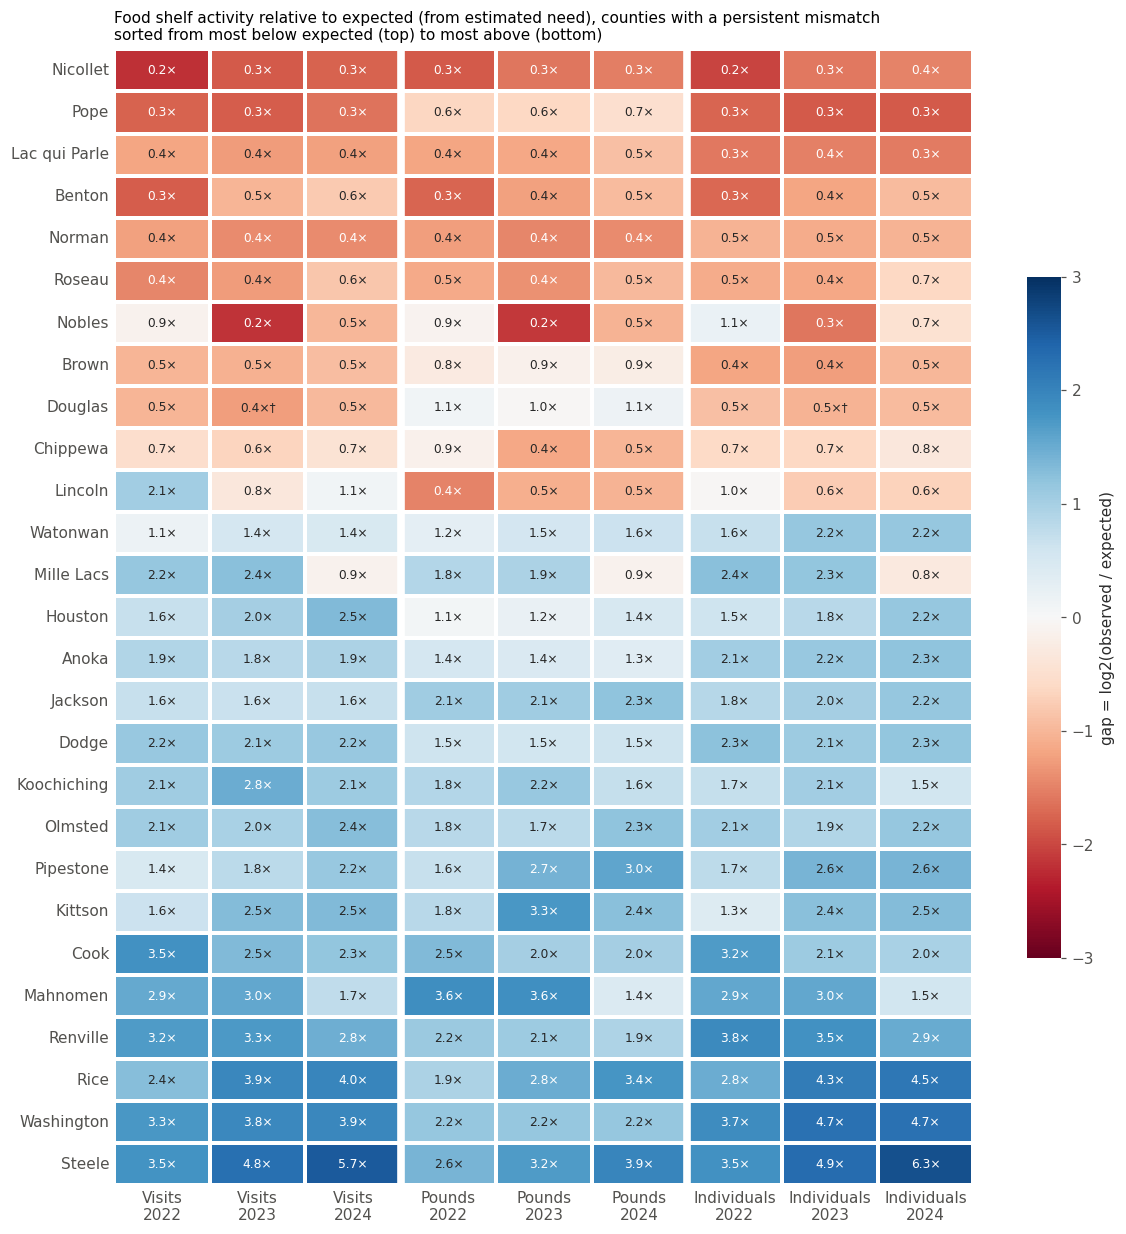

In [36]:
heat_counties = sorted(set(persistent_any["county"]) | set(per.loc[per["reporting_sensitive"], "county"]))
heat_long = long[long["county"].isin(heat_counties)].copy()
heat_long["col"] = heat_long["metric"].map(NICE) + "\n" + heat_long["year"].astype(str)
col_order = [f"{NICE[m]}\n{y}" for m in METRICS for y in [2022, 2023, 2024]]
order = (county_summary.set_index("county").loc[heat_counties, "mean_gap_all"].sort_values().index)

gap_mat = heat_long.pivot(index="county", columns="col", values="gap").loc[order, col_order]
lab = heat_long.assign(lab=lambda d: (2 ** d["gap"]).map(lambda v: f"{v:.1f}×") + np.where(d["concern"], "†", ""))
lab_mat = lab.pivot(index="county", columns="col", values="lab").loc[order, col_order]

fig, ax = plt.subplots(figsize=(11, 0.36 * len(order) + 1.6))
sns.heatmap(gap_mat, cmap="RdBu", center=0, vmin=-3, vmax=3, annot=lab_mat, fmt="", annot_kws={"fontsize": 8},
            linewidths=1.5, linecolor="white", cbar_kws={"label": "gap = log2(observed / expected)", "shrink": 0.6}, ax=ax)
for x in [3, 6]:
    ax.axvline(x, color="white", lw=5)
ax.grid(False); ax.tick_params(length=0)
ax.set_xlabel(""); ax.set_ylabel("")
ax.set_title("Food shelf activity relative to expected (from estimated need), counties with a persistent mismatch\n"
             "sorted from most below expected (top) to most above (bottom)", loc="left", fontsize=10)
plt.tight_layout()
plt.show()

- **The low side is very stable:** Nicollet, Pope, Lac qui Parle and Norman sit at about 0.2–0.5× in nearly every cell.
- **The high side has the extremes, and some are growing:** Steele reaches 5.7× on visits and 6.3× on individuals in 2024.
- **Fading:** Mahnomen and Mille Lacs are lighter in 2024.
- **Douglas** carries the only † (2023).

## 23. Shortlist

A county is shortlisted if it meets **all** of:
1. **Persistent on at least 2 of the 3 metrics** in the same direction (clean years only).
2. **The same direction under at least one alternative method** (B or C) for each of those metrics.
3. **Average gap of at least a factor of 2** (|mean gap| ≥ 1).

In [37]:
shortlist = county_summary[
    (county_summary[["metrics_persistent_low", "metrics_persistent_high"]].max(axis=1) >= 2)
    & (county_summary["direction"] != "mixed")
    & (county_summary["min_methods_agree"] >= 2)
    & (county_summary["mean_gap_all"].abs() >= 1)
].copy()
shortlist["order"] = np.where(shortlist["direction"] == "lower than expected", shortlist["mean_gap_all"], -shortlist["mean_gap_all"])
shortlist = shortlist.sort_values(["direction", "order"], ascending=[False, True]).drop(columns="order")
county_summary["shortlist"] = county_summary["fips"].isin(shortlist["fips"])

print("Shortlist size:", len(shortlist), "|", shortlist["direction"].value_counts().to_dict())
shortlist[["county", "direction", "consistency", "mean_gap_all", "times_expected_all", "mean_fi_rate",
           "need_rate_vs_state", "min_methods_agree", "one_year_or_mixed_flags"]].round(3)

Shortlist size: 12 | {'higher than expected': 7, 'lower than expected': 5}


,county,direction,consistency,mean_gap_all,times_expected_all,mean_fi_rate,need_rate_vs_state,min_methods_agree,one_year_or_mixed_flags
51,Nicollet,lower than expected,all 3 metrics,-1.764,0.294,0.104,at/below median,3,0
60,Pope,lower than expected,"2 metrics (individuals, visits)",-1.376,0.385,0.106,at/below median,3,0
36,Lac qui Parle,lower than expected,all 3 metrics,-1.285,0.410,0.104,at/below median,3,0
53,Norman,lower than expected,all 3 metrics,-1.264,0.416,0.112,above median,3,0
67,Roseau,lower than expected,all 3 metrics,-1.107,0.464,0.107,at/below median,3,0
73,Steele,higher than expected,all 3 metrics,2.046,4.131,0.097,at/below median,3,0
81,Washington,higher than expected,all 3 metrics,1.718,3.289,0.074,at/below median,3,0
65,Rice,higher than expected,all 3 metrics,1.685,3.215,0.098,at/below median,3,0
64,Renville,higher than expected,all 3 metrics,1.474,2.778,0.116,above median,2,0
43,Mahnomen,higher than expected,all 3 metrics,1.301,2.464,0.163,above median,3,0


In [38]:
# Who just missed the shortlist? (persistent on >= 2 metrics, but failed the method or size test)
near = county_summary[
    (county_summary[["metrics_persistent_low", "metrics_persistent_high"]].max(axis=1) >= 2)
    & ~county_summary["shortlist"]]
county_summary["priority"] = np.select([county_summary["shortlist"], county_summary["fips"].isin(near["fips"])],
                                       ["shortlist", "second tier"], default="")
near[["county", "direction", "consistency", "mean_gap_all", "times_expected_all", "min_methods_agree"]].round(2)

,county,direction,consistency,mean_gap_all,times_expected_all,min_methods_agree
4,Benton,lower than expected,all 3 metrics,-1.26,0.42,1
7,Brown,lower than expected,"2 metrics (individuals, visits)",-0.79,0.58,3
15,Cook,higher than expected,all 3 metrics,1.27,2.41,1
19,Dodge,higher than expected,"2 metrics (individuals, visits)",0.96,1.95,2
31,Jackson,higher than expected,"2 metrics (individuals, pounds)",0.93,1.91,1
34,Kittson,higher than expected,all 3 metrics,1.11,2.16,1
47,Mille Lacs,higher than expected,"2 metrics (individuals, visits)",0.68,1.60,3


In [39]:
# Context only (NOT used for selection): where do the shortlisted counties sit on MMG's need RATE?
(shortlist.groupby(["direction", "need_rate_vs_state"])["county"].apply(", ".join)
          .unstack(fill_value="—").rename_axis(columns="food insecurity rate vs. state median"))

food insecurity rate vs. state median,above median,at/below median
direction,,
higher than expected,"Renville, Mahnomen, Pipestone","Steele, Washington, Rice, Olmsted"
lower than expected,Norman,"Nicollet, Pope, Lac qui Parle, Roseau"


**Shortlist: 12 counties**, none reporting-sensitive.

| Lower than expected | Higher than expected |
|---|---|
| Nicollet (0.29×), Pope (0.39×), Lac qui Parle (0.41×), Norman (0.42×), Roseau (0.46×) | Steele (4.1×), Washington (3.3×), Rice (3.2×), Renville (2.8×), Mahnomen (2.5×), Pipestone (2.1×), Olmsted (2.0×) |

**Second tier:**
- **Benton, Cook, Kittson, Jackson:** the result depends on the method (small counties are where B and C are least favorable to "high").
- **Brown, Dodge, Mille Lacs:** consistent, but the gap is under 2×.

**Need rate, as context only:**
- Higher than expected with an at/below-median need rate: Steele, Washington, Rice, Olmsted (the "lower need / higher activity" type).
- Higher than expected with an above-median rate: Mahnomen, Renville, Pipestone.
- Among the lower group, **only Norman** has an above-median need rate.

### 23a. Where the shortlisted counties sit

Totals scatterplots (log scales, 2024): dark line = expected activity, dotted lines = 2× and ½×. Only shortlisted counties are labeled.

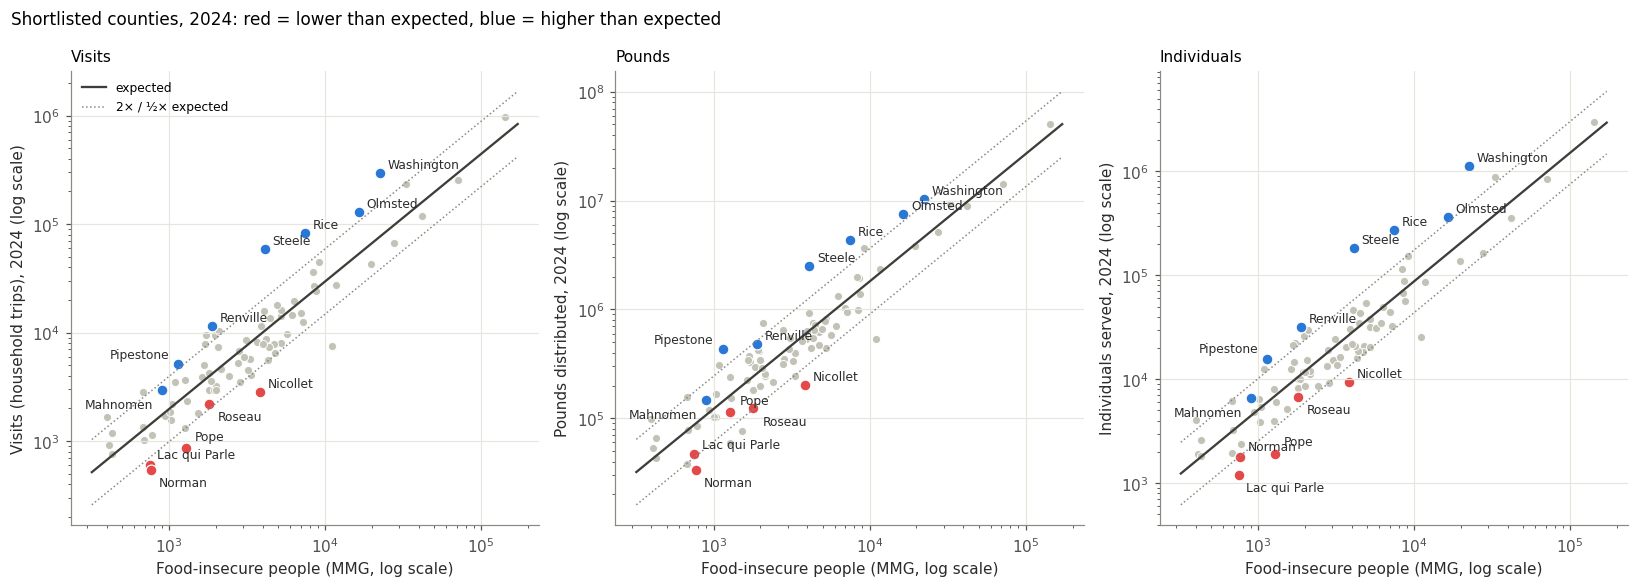

In [40]:
YEAR_SHOW = 2024
# Small manual label offsets (points) so neighbouring labels don't overlap: (dx, dy, alignment)
# Norman and Lac qui Parle almost overlap: put the label of whichever point is lower in that panel underneath it.
NUDGE = {"Roseau": (6, -11, "left"),
         "Pope": (6, 5, "left"), "Mahnomen": (-6, -12, "right"), "Pipestone": (-6, 4, "right")}
d_show = mm[mm["year"] == YEAR_SHOW]
low_names = set(shortlist.loc[shortlist["direction"] == "lower than expected", "county"])
high_names = set(shortlist.loc[shortlist["direction"] == "higher than expected", "county"])

fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))
for ax, m in zip(axes, METRICS):
    fit = fits[(fits["year"] == YEAR_SHOW) & (fits["metric"] == m)].iloc[0]
    xs = np.linspace(d_show["fi_persons"].min() * 0.8, d_show["fi_persons"].max() * 1.2, 100)
    expected_line = d_show[f"{m}_expected"].iloc[0] / d_show["fi_persons"].iloc[0] ** fit["slope"] * xs ** fit["slope"]
    ax.plot(xs, expected_line, color="#3d3d3a", lw=1.5, label="expected")
    ax.plot(xs, expected_line * 2, color="#8a8984", lw=1, ls=":", label="2× / ½× expected")
    ax.plot(xs, expected_line / 2, color="#8a8984", lw=1, ls=":")
    other = ~d_show["county"].isin(low_names | high_names)
    ax.scatter(d_show.loc[other, "fi_persons"], d_show.loc[other, m], s=28, color="#c3c2b7", edgecolor="white", linewidth=0.6)
    for names, marker_color in [(low_names, "#e34948"), (high_names, "#2a78d6")]:
        sel = d_show[d_show["county"].isin(names)]
        ax.scatter(sel["fi_persons"], sel[m], s=50, color=marker_color, edgecolor="white", linewidth=0.8)
        for _, r in sel.iterrows():
            dx, dy, ha = NUDGE.get(r["county"], (5, 3, "left"))
            if r["county"] in ("Norman", "Lac qui Parle"):
                other = "Lac qui Parle" if r["county"] == "Norman" else "Norman"
                dy = 4 if r[m] > d_show.loc[d_show["county"] == other, m].iloc[0] else -11
            ax.annotate(r["county"], (r["fi_persons"], r[m]), xytext=(dx, dy), textcoords="offset points",
                        ha=ha, fontsize=8, color="#2b2b2b")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Food-insecure people (MMG, log scale)")
    ax.set_ylabel(f"{LABEL[m]}, {YEAR_SHOW} (log scale)")
    ax.set_title(NICE[m], loc="left", fontsize=10)
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle(f"Shortlisted counties, {YEAR_SHOW}: red = lower than expected, blue = higher than expected",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

The shortlisted counties sit on or beyond the 2× / ½× lines and range from very small (Lac qui Parle, Mahnomen) to large (Washington), so they are not simply the biggest or smallest counties.

## 24. Save the mismatch tables

`q1_county_year_mismatch.csv` (county × year: expected activity, gap, flag, reporting concern per metric) and `q1_county_mismatch_summary.csv` (one row per county: patterns, direction, size, shortlist). Wilkin is included but not scored. Existing cleaned files are not modified.

In [41]:
year_cols = (["fips", "county", "year", "fi_rate", "fi_persons", "population", "need_rate_vs_state",
              "months_reported", "site_months", "site_months_missing", "share_site_months_missing", "incomplete",
              "typo_fixed_rows"]
             + [f"{m}{s}" for m in METRICS for s in ["", "_expected", "_gap", "_flag", "_report_concern",
                                                     "_share_suspect", "_gap_B", "_gap_C"]])
wilkin = df.loc[df["visits"].isna(), ["fips", "county", "year", "fi_rate", "fi_persons", "population"]]
county_year_out = (pd.concat([mm[year_cols], wilkin], ignore_index=True)
                     .assign(note=lambda d: np.where(d["visits"].isna(), "no food shelf in data; not scored", ""))
                     .sort_values(["county", "year"]))

pattern_wide = per.pivot(index="fips", columns="metric", values="pattern_clean").add_suffix("_pattern")
gap_wide = per.pivot(index="fips", columns="metric", values="mean_gap").add_suffix("_mean_gap")
summary_out = (county_summary.merge(pattern_wide, on="fips").merge(gap_wide, on="fips"))
wilkin_row = (df[df["county"] == "Wilkin"].groupby(["fips", "county"], as_index=False)["fi_rate"].mean()
                .rename(columns={"fi_rate": "mean_fi_rate"})
                .assign(direction="not scored (no food shelf in data)", shortlist=False))
summary_out = pd.concat([summary_out, wilkin_row], ignore_index=True).sort_values("county")
count_cols = ["metrics_persistent_low", "metrics_persistent_high", "metrics_reporting_sensitive",
              "min_methods_agree", "one_year_or_mixed_flags"]
summary_out[count_cols] = summary_out[count_cols].astype("Int64")   # whole numbers; blank for Wilkin

county_year_out.to_csv(PROCESSED / "q1_county_year_mismatch.csv", index=False)
summary_out.to_csv(PROCESSED / "q1_county_mismatch_summary.csv", index=False)
print("q1_county_year_mismatch.csv:", county_year_out.shape)
print("q1_county_mismatch_summary.csv:", summary_out.shape)

q1_county_year_mismatch.csv: (261, 38)
q1_county_mismatch_summary.csv: (87, 21)


## 25. Part 3 summary

- **Mismatch** = activity at least 2× or at most ½ of what counties with a similar number of food-insecure people record, persistent in ≥ 2 of 3 years.
- **Shortlist (12):**
  - Lower than expected: **Nicollet, Pope, Lac qui Parle, Norman, Roseau**. These are stable every year.
  - Higher than expected: **Steele, Washington, Rice, Renville, Mahnomen, Pipestone, Olmsted**. Steele and Rice are growing.
- **Second tier:** Benton, Cook, Kittson, Jackson, Brown, Dodge, Mille Lacs.
- **Possible data-quality cases:** Douglas, Grant, Stevens. Wilkin has no food shelf and isn't scored.
- **Caveats:** "expected" is relative to other Minnesota counties, not a standard of service. The ×2 cutoff is a judgment call (the continuous gaps are saved). Activity is recorded where the food shelf is, not where clients live.

---

# Part 4: What county characteristics might help explain the mismatches?

> Using public data, do county characteristics offer **plausible** explanations for why need estimates and food shelf activity don't line up?

This is an investigation of **associations**, not causes. Different counties may mismatch for different reasons.

## 26. Which characteristics, and why

| Characteristic | Source | Why it might matter |
|---|---|---|
| **Sites per 10,000 residents** | `foodshelf_county_month.csv` (average monthly sites operating, reported or not ÷ ACS population) | availability |
| **Visits per reporting site-month** | same file | describes *many* vs. *busy* sites (section 33). Built from activity, so not an explanation by itself |
| **Avg miles to nearest food shelf**, **% of residents > 10 miles away** | Census 2020 population centers + site locations from `Organization.xlsx` (section 28a) | physical access |
| **% of residents whose nearest food shelf is in another county** | same (section 28a) | cross-county use |
| **Poverty rate** | ACS S1701 | economic hardship |
| **No-vehicle households %** | ACS B08201 (with margin of error) | one possible access barrier (not the same as "no transportation") |
| **Rurality** | MMG `rucc_2023` (1–3 metro, 4–9 rural) | settlement pattern |
| **Food-insecure above the SNAP income limit %** | MMG | people who can't get SNAP may rely more on food shelves |
| **SNAP participation %** | `snap_2022_2024_clean.csv`, only where the agency is a single county (section 27) | more need met by SNAP |

ACS values are 5-year estimates, so all characteristics are averaged over 2022–2024 and treated as **stable county traits**. Other poverty variants and the "0–1 vehicle" rate are left out because they overlap with the measures above.

## 27. Can SNAP be joined to counties correctly?

The README warns that SNAP is reported by **county agency**, not by county, and that `county_code` is the state's own numbering, **not FIPS**. We check the structure before using it.

In [42]:
snap = pd.read_csv(PROCESSED / "snap_2022_2024_clean.csv")
print("SNAP rows:", snap.shape, "| years:", sorted(snap["year"].unique()),
      "| months per year:", snap.groupby("year")["month"].nunique().to_dict())
print("Duplicate agency-year-month rows:", int(snap.duplicated(["county_code", "year", "month"]).sum()))

# Match agency names to official county names (uppercase) -> FIPS. We never treat county_code as FIPS.
county_names = mmg[["fips", "county"]].drop_duplicates().assign(agency=lambda d: d["county"].str.upper())
agencies = snap[["county_code", "county"]].drop_duplicates().rename(columns={"county": "agency"})
agency_map = agencies.merge(county_names, on="agency", how="left", validate="one_to_one")

print(f"\nAgencies: {len(agencies)} | matched one-to-one to a single county: {agency_map['fips'].notna().sum()}")
print("Agencies that are NOT a single county:", agency_map.loc[agency_map["fips"].isna(), "agency"].tolist())
print("Counties with no agency of their own:", sorted(set(county_names["county"]) - set(agency_map["county"].dropna())))

SNAP rows: (3132, 7) | years: [2022, 2023, 2024] | months per year: {2022: 12, 2023: 12, 2024: 12}
Duplicate agency-year-month rows: 0

Agencies: 87 | matched one-to-one to a single county: 82
Agencies that are NOT a single county: ['WPHS', 'MNPRAIRIE', 'MILLE-LACS-BAND TRIBE', 'WHITE EARTH NATION', 'RED LAKE INDIAN RESV']
Counties with no agency of their own: ['Dodge', 'Grant', 'Pope', 'Steele', 'Waseca']


| Agency type | Decision |
|---|---|
| **82 single-county agencies** | joined by name → FIPS (checked one-to-one). Usable. |
| **Combined:** `MNPRAIRIE` (Dodge + Steele + Waseca), `WPHS` (Grant + Pope) | totals can't be split. A **regional** rate is shown in profiles only, labeled as such, and these counties are left out of SNAP statistics. |
| **Tribal:** White Earth Nation, Red Lake, Mille Lacs Band | counted separately and overlapping several counties, so county SNAP counts are too low there. The overlapping counties are **excluded** from SNAP statistics: White Earth → Mahnomen, Becker, Clearwater; Red Lake → Beltrami, Clearwater; Mille Lacs Band → Mille Lacs, Pine, Aitkin. This list is outside knowledge, not from the data. |

In [43]:
TRIBAL_OVERLAP = ["Mahnomen", "Becker", "Clearwater", "Beltrami", "Mille Lacs", "Pine", "Aitkin"]
COMBINED_AGENCY = {"MNPRAIRIE": ["Dodge", "Steele", "Waseca"], "WPHS": ["Grant", "Pope"]}

pov_full = (pd.read_csv(PROCESSED / "poverty_2022_2024_clean.csv", dtype={"county_geoid": str})
              .rename(columns={"county_geoid": "fips"}))

# Average monthly SNAP participants per agency-year
snap_year = snap.groupby(["county", "year"], as_index=False)["snap_people"].mean().rename(columns={"county": "agency"})

# County-level rate: single-county agencies only
snap_county = (snap_year.merge(agency_map.dropna(subset=["fips"])[["agency", "fips"]], on="agency", how="inner")
                        .merge(pov_full[["fips", "year", "population", "poverty_rate"]], on=["fips", "year"],
                               how="left", validate="one_to_one"))
snap_county["snap_rate"] = snap_county["snap_people"] / snap_county["population"] * 100
snap_county = snap_county.merge(county_names[["fips", "county"]], on="fips")

# Regional rates for the two combined agencies (shown in profiles only, clearly labeled)
regional_rows = []
for agency, members in COMBINED_AGENCY.items():
    member_pop = (pov_full[pov_full["county"].isin([m.upper() for m in members])]
                  .groupby("year")["population"].sum())
    people = snap_year[snap_year["agency"] == agency].set_index("year")["snap_people"]
    rate = (people / member_pop * 100).mean()
    for m in members:
        regional_rows.append({"county": m, "snap_rate_regional": rate, "snap_region": f"{agency} ({' + '.join(members)})"})
snap_regional = pd.DataFrame(regional_rows)

# Evidence check: SNAP participation relative to poverty, tribal-overlap counties vs. the rest
chk = snap_county.groupby("county")[["snap_rate", "poverty_rate"]].mean()
chk["snap_per_poverty_point"] = chk["snap_rate"] / chk["poverty_rate"]
chk["group"] = np.where(chk.index.isin(TRIBAL_OVERLAP), "tribal overlap", "other single-county agencies")
display(chk.groupby("group")["snap_per_poverty_point"].median().round(2).rename("median SNAP rate ÷ poverty rate").to_frame())
chk.loc[TRIBAL_OVERLAP, ["snap_rate", "poverty_rate", "snap_per_poverty_point"]].round(2)

,median SNAP rate ÷ poverty rate
group,
other single-county agencies,0.75
tribal overlap,0.64


,snap_rate,poverty_rate,snap_per_poverty_point
county,,,
Mahnomen,5.49,19.93,0.28
Becker,6.46,11.60,0.56
Clearwater,8.38,11.70,0.72
Beltrami,8.97,16.07,0.56
Mille Lacs,8.78,10.63,0.83
Pine,10.11,10.73,0.94
Aitkin,8.10,12.60,0.64


In the tribal-overlap counties, SNAP is lower relative to poverty (median ratio 0.64 vs. 0.75), and Mahnomen stands out most (19.9% poverty but 5.5% SNAP). The effect isn't uniform (Mille Lacs and Pine look normal), so all 7 are excluded rather than selectively corrected.

**Result:** county SNAP rates for **74 counties**; regional only for Steele and Pope; not usable for Mahnomen. SNAP is left out of the regression.

## 28. Build and validate the county characteristic table

Every join is on **FIPS + year** with `validate="one_to_one"` so a many-to-many join would raise an error. We check row counts after each step.

In [44]:
veh = (pd.read_csv(PROCESSED / "vehicle_access_2022_2024_clean.csv", dtype={"county_geoid": str})
         .rename(columns={"county_geoid": "fips"}))
for name, d in [("poverty", pov_full), ("vehicle access", veh), ("MMG", mmg)]:
    print(f"{name:15s} rows={len(d)} years={sorted(d['year'].unique())} counties={d['fips'].nunique()} "
          f"duplicate county-years={int(d.duplicated(['fips', 'year']).sum())}")

sites_cy = (fs_month[fs_month["year"].between(2022, 2024)]
            .groupby(["fips", "year"], as_index=False)
            .agg(avg_sites=("n_sites", "mean"), avg_sites_reported=("n_sites_reported", "mean")))

chars_cy = (pov_full[["fips", "year", "population", "poverty_rate"]]
            .merge(veh[["fips", "year", "no_vehicle_rate", "no_vehicle_rate_moe"]], on=["fips", "year"], how="left", validate="one_to_one")
            .merge(mmg[["fips", "year", "rucc_2023", "rural", "pct_fi_above_snap_threshold"]], on=["fips", "year"], how="left", validate="one_to_one")
            .merge(sites_cy, on=["fips", "year"], how="left", validate="one_to_one")
            .merge(snap_county[["fips", "year", "snap_rate"]], on=["fips", "year"], how="left", validate="one_to_one"))
chars_cy["sites_per_10k"] = chars_cy["avg_sites"] / chars_cy["population"] * 10_000
chars_cy["pct_fi_above_snap_threshold"] = chars_cy["pct_fi_above_snap_threshold"] * 100   # to percent

print("\nCounty-year rows:", len(chars_cy), "| counties:", chars_cy["fips"].nunique(),
      "| duplicate county-years:", int(chars_cy.duplicated(["fips", "year"]).sum()))
print("Missing values:\n", chars_cy.isna().sum()[lambda s: s > 0].to_string())

poverty         rows=261 years=[2022, 2023, 2024] counties=87 duplicate county-years=0
vehicle access  rows=261 years=[2022, 2023, 2024] counties=87 duplicate county-years=0
MMG             rows=261 years=[2022, 2023, 2024] counties=87 duplicate county-years=0

County-year rows: 261 | counties: 87 | duplicate county-years: 0
Missing values:
 snap_rate    15


In [45]:
# Activity per reporting site-month, from the Part 3 county-year table (activity / site-months that reported)
mm["reported_site_months"] = mm["site_months"] - mm["site_months_missing"]
mm["visits_per_site_month"] = mm["visits"] / mm["reported_site_months"]

# Average 2022-2024 into stable county characteristics (ACS windows overlap, so we don't read year-to-year changes)
chars = (chars_cy.groupby("fips", as_index=False)
         .agg(population=("population", "mean"), poverty_rate=("poverty_rate", "mean"),
              no_vehicle_rate=("no_vehicle_rate", "mean"), no_vehicle_rate_moe=("no_vehicle_rate_moe", "mean"),
              rucc_2023=("rucc_2023", "first"), rural=("rural", "first"),
              pct_fi_above_snap_threshold=("pct_fi_above_snap_threshold", "mean"),
              avg_sites=("avg_sites", "mean"), avg_sites_reported=("avg_sites_reported", "mean"),
              sites_per_10k=("sites_per_10k", "mean"), snap_rate=("snap_rate", "mean"))
         .merge(mm.groupby("fips", as_index=False)["visits_per_site_month"].mean(), on="fips", how="left", validate="one_to_one"))

# SNAP: exclude tribal-overlap counties from county-level SNAP (combined-agency counties are already blank)
chars = chars.merge(county_names[["fips", "county"]], on="fips", validate="one_to_one")
chars["snap_status"] = np.select(
    [chars["county"].isin(TRIBAL_OVERLAP), chars["county"].isin(snap_regional["county"]), chars["snap_rate"].notna()],
    ["excluded: tribal agency overlap (understated)", "regional only: combined agency", "county agency"], default="missing")
chars.loc[chars["county"].isin(TRIBAL_OVERLAP), "snap_rate"] = np.nan
chars = chars.merge(snap_regional, on="county", how="left", validate="one_to_one")

# Join to the Part 3 county summary (86 scored counties; Wilkin has no food shelf and was not scored)
gaps_wide = per.pivot(index="fips", columns="metric", values="mean_gap").add_suffix("_mean_gap").reset_index()
prof = (county_summary[["fips", "county", "direction", "consistency", "mean_gap_all", "times_expected_all",
                        "need_rate_vs_state", "mean_fi_rate", "metrics_reporting_sensitive", "priority"]]
        .merge(gaps_wide, on="fips", how="left", validate="one_to_one")
        .merge(chars.drop(columns="county"), on="fips", how="left", validate="one_to_one"))
prof["direction"] = prof["direction"].replace("", "no persistent mismatch")

print("Profile table:", prof.shape, "| counties:", prof["fips"].nunique())
print("Counties in characteristics but not scored in Part 3:", sorted(set(chars["county"]) - set(prof["county"])))
print("SNAP status:", prof["snap_status"].value_counts().to_dict())
print("Missing values in characteristics:\n", prof[["poverty_rate", "no_vehicle_rate", "rucc_2023", "sites_per_10k",
      "visits_per_site_month", "pct_fi_above_snap_threshold", "snap_rate"]].isna().sum().to_string())

Profile table: (86, 28) | counties: 86
Counties in characteristics but not scored in Part 3: ['Wilkin']
SNAP status: {'county agency': 74, 'excluded: tribal agency overlap (understated)': 7, 'regional only: combined agency': 5}
Missing values in characteristics:
 poverty_rate                    0
no_vehicle_rate                 0
rucc_2023                       0
sites_per_10k                   0
visits_per_site_month           0
pct_fi_above_snap_threshold     0
snap_rate                      12


Every source has 261 rows (87 counties × 3 years) with no duplicate county-years, and every join is one-to-one. The only missing values are SNAP for the combined-agency counties (intentional). The profile table holds the 86 counties scored in Part 3. `n_sites` counts sites that **existed**, whether or not they reported, so "sites per 10k" measures availability, not reporting.

### 28a. Distance to the nearest food shelf

"Sites per 10,000 residents" only counts sites. A county can have many sites clustered in one town while most residents live far away. Distance measures **where sites are relative to where people live**.

**Two public inputs:**
- **Where people live:** the Census 2020 population-weighted centers of Minnesota's 4,706 block groups (neighborhoods of roughly 1,000–3,000 people).
- **Where food shelves are:** each site's 2020 Census block in `Organization.xlsx` (provided instead of the street address), converted to coordinates with the Census TIGERweb service.

**Which sites:** fixed-location food shelves (Food Shelf, Brick and Mortar, Tribal, College) with recorded activity in 2022–2024. Outreach programs (home delivery) and mobile pantries are left out, because their recorded address isn't where food is handed out.

**Three county measures** (weighted by block-group population):
1. **Average straight-line miles** to the nearest food shelf.
2. **% of residents more than 10 miles** from one.
3. **% of residents whose nearest food shelf is in another county**, a first, indirect look at cross-county use.

Downloads are cached in `Data/local/` (git-ignored), so the notebook only needs the internet on its first run.

In [46]:
import requests

LOCAL = ROOT / "Data" / "local"          # git-ignored cache for downloaded public files
LOCAL.mkdir(parents=True, exist_ok=True)

# 1) Where people live: Census 2020 population-weighted centers of every Minnesota block group
CENPOP_URL = "https://www2.census.gov/geo/docs/reference/cenpop2020/blkgrp/CenPop2020_Mean_BG27.txt"
cenpop_file = LOCAL / "CenPop2020_Mean_BG27.txt"
if not cenpop_file.exists():
    cenpop_file.write_bytes(requests.get(CENPOP_URL, timeout=60).content)
bgpop = pd.read_csv(cenpop_file, encoding="utf-8-sig", dtype=str)
bgpop = bgpop.assign(fips=bgpop["STATEFP"] + bgpop["COUNTYFP"], population=bgpop["POPULATION"].astype(int),
                     lat=bgpop["LATITUDE"].astype(float), lon=bgpop["LONGITUDE"].astype(float))
print(f"Block groups: {len(bgpop):,} | counties: {bgpop['fips'].nunique()} | 2020 population: {bgpop['population'].sum():,}")

Block groups: 4,706 | counties: 87 | 2020 population: 5,706,494


In [47]:
# 2) Food shelf sites active 2022-2024 (meal programs excluded, as in the county file), joined to Organization
org = pd.read_excel(ROOT / "Data" / "Organization.xlsx", usecols=["__ID", "County", "City", "block_geoid", "is_zip_centroid"])
assert org["__ID"].is_unique
site_all = pd.read_csv(PROCESSED / "foodshelf_site_month.csv", dtype={"fips": str})
site_all = site_all[(site_all["site_group"] != "meal") & site_all["year"].between(2022, 2024)]
sites = (site_all.groupby("site_id")
         .agg(fips=("fips", lambda x: x.mode().iat[0]), county=("county", "first"),
              agency_type=("agency_type", lambda x: x.mode().iat[0] if x.notna().any() else None),
              visits=("visits", "sum"))
         .reset_index()
         # exact ID match: some IDs have decimals (e.g. 14681 and 14681.1 are different sites), so never round them
         .merge(org, left_on="site_id", right_on="__ID", how="left", validate="one_to_one"))
sites["block"] = sites["block_geoid"].map(lambda v: f"{int(v):015d}" if pd.notna(v) else None)
sites["block_fips"] = sites["block"].str[:5]
print(f"Sites: {len(sites)} | matched to Organization: {sites['__ID'].notna().sum()} | with a block: {sites['block'].notna().sum()} "
      f"| located only by ZIP centre: {int((sites['is_zip_centroid'] == 1).sum())}")

# 3) Each block's center point from the Census TIGERweb service (cached after the first run)
TIGER_URL = "https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/tigerWMS_Census2020/MapServer/10/query"
coords_file = LOCAL / "foodshelf_block_coords.csv"
blocks = sorted(sites["block"].dropna().unique())
cached = pd.read_csv(coords_file, dtype={"GEOID": str}) if coords_file.exists() else pd.DataFrame(columns=["GEOID", "lat", "lon"])
todo = [b for b in blocks if b not in set(cached["GEOID"])]
fetched = []
for i in range(0, len(todo), 50):
    query = "GEOID IN (%s)" % ",".join(f"'{b}'" for b in todo[i:i + 50])
    reply = requests.get(TIGER_URL, params={"where": query, "outFields": "GEOID,INTPTLAT,INTPTLON",
                                            "returnGeometry": "false", "f": "json"}, timeout=60).json()
    fetched += [{"GEOID": f["attributes"]["GEOID"], "lat": float(f["attributes"]["INTPTLAT"]),
                 "lon": float(f["attributes"]["INTPTLON"])} for f in reply["features"]]
new_xy = pd.DataFrame(fetched, columns=["GEOID", "lat", "lon"])
block_xy = pd.concat([f for f in (cached, new_xy) if len(f)], ignore_index=True).drop_duplicates("GEOID")
block_xy.to_csv(coords_file, index=False)
sites = sites.merge(block_xy, left_on="block", right_on="GEOID", how="left", validate="many_to_one")
print(f"Blocks needed: {len(blocks)} | located: {block_xy['GEOID'].isin(blocks).sum()} | missing: {len(set(blocks) - set(block_xy['GEOID']))}")

Sites: 530 | matched to Organization: 530 | with a block: 512 | located only by ZIP centre: 7
Blocks needed: 467 | located: 467 | missing: 0


**Location check.** Before using locations, we compare each site's block county with the county in the cleaned food shelf data.

In [48]:
county_name = dict(zip(fs_month["fips"], fs_month["county"]))
sites["block_county"] = sites["block_fips"].map(county_name)
loc_mismatch = sites[sites["block"].notna() & (sites["block_fips"] != sites["fips"])]
print(f"Sites whose block is in a different county than reported: {len(loc_mismatch)} of {sites['block'].notna().sum()} "
      f"({loc_mismatch['visits'].sum() / sites['visits'].sum():.1%} of 2022-2024 visits)")
loc_mismatch[["site_id", "county", "block_county", "City", "agency_type", "visits"]].sort_values("visits", ascending=False)

Sites whose block is in a different county than reported: 20 of 512 (2.1% of 2022-2024 visits)


,site_id,county,block_county,City,agency_type,visits
402,14681.1,Hennepin,Ramsey,NaN,Food Shelf,24609.0
341,14473.0,Anoka,Scott,Elko New Market,Food Shelf,23607.0
476,15212.0,Sherburne,Anoka,NaN,Food Shelf,23110.0
89,1188.0,Wright,Hennepin,Brooklyn Park,Food Shelf,21584.0
148,1258.0,Stearns,Benton,St. Cloud,Food Shelf,17199.0
388,14647.0,Ramsey,Hennepin,Brooklyn Park,Other Non-Profit,12791.0
370,14549.0,Chisago,Anoka,Wyoming,Food Shelf,6691.0
401,14680.1,Koochiching,St. Louis,Nett Lake,Tribal Program,5897.0
146,1256.0,Hennepin,Ramsey,NaN,Food Shelf,4449.0
229,13640.0,Mower,Olmsted,Rochester,Brick and Mortar Site,2134.0


These mismatches fall into three groups:
- **Border towns** (St. Cloud, Eden Valley, Nett Lake, Wyoming): the site may really sit on the county line.
- **The address is an office elsewhere** (e.g. a Wright County food shelf with a Brooklyn Park address, a Mower site with a Rochester address).
- **Twin Cities sites** whose blocks fall on the other side of the Hennepin/Ramsey line.

The reported county comes from the food shelves' own monthly reports, so a block location is **trusted only when its county matches**. Mismatched sites are left out of the main measure, and a sensitivity version adds them back.

In [49]:
FIXED_TYPES = ["Food Shelf", "Brick and Mortar Site", "Tribal Program", "College Campus Program"]
usable = sites["agency_type"].isin(FIXED_TYPES) & (sites["visits"] > 0) & sites["lat"].notna()
loc_main = sites[usable & (sites["block_fips"] == sites["fips"])]
loc_all = sites[usable]
print(f"Fixed-location sites with activity and a location: {len(loc_all)} | used in the main measure: {len(loc_main)}")


def miles(lat1, lon1, lat2, lon2):
    """Straight-line (great-circle) distance in miles."""
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 3958.8 * 2 * np.arcsin(np.sqrt(a))


def access_measures(locs):
    d = miles(bgpop["lat"].values[:, None], bgpop["lon"].values[:, None], locs["lat"].values[None, :], locs["lon"].values[None, :])
    nearest = d.argmin(axis=1)
    bg = bgpop.assign(dist_mi=d[np.arange(len(bgpop)), nearest], nearest_fips=locs["block_fips"].values[nearest])
    bg["over_10mi"] = bg["dist_mi"] > 10
    bg["nearest_other_county"] = bg["nearest_fips"] != bg["fips"]
    w = bg["population"]
    agg = (bg.assign(d=bg["dist_mi"] * w, f=bg["over_10mi"] * w, o=bg["nearest_other_county"] * w)
             .groupby("fips")[["d", "f", "o", "population"]].sum())
    out = pd.DataFrame({"mean_dist_mi": agg["d"] / agg["population"],
                        "pct_over_10mi": agg["f"] / agg["population"] * 100,
                        "pct_nearest_other_county": agg["o"] / agg["population"] * 100}).reset_index()
    return out, bg


access, bg_near = access_measures(loc_main)
access_all, _ = access_measures(loc_all)
ACCESS_COLS = ["mean_dist_mi", "pct_over_10mi", "pct_nearest_other_county"]
print(f"Counties: {len(access)} | population covered: {bg_near['population'].sum():,}")
print("Agreement with the version that keeps the 20 mismatched sites (Spearman):",
      {c: round(access[c].corr(access_all[c], method="spearman"), 3) for c in ACCESS_COLS})

# Add to the county tables used below (safe to re-run)
prof = prof.drop(columns=ACCESS_COLS, errors="ignore").merge(access, on="fips", how="left", validate="one_to_one")
chars = chars.drop(columns=ACCESS_COLS, errors="ignore").merge(access, on="fips", how="left", validate="one_to_one")
print("Missing access values in the profile table:", int(prof[ACCESS_COLS].isna().sum().sum()))
print("Wilkin (no food shelf in the data):", chars.loc[chars["county"] == "Wilkin", ACCESS_COLS].round(1).to_dict("records"))
access[ACCESS_COLS].describe().round(1)

Fixed-location sites with activity and a location: 450 | used in the main measure: 435


Counties: 87 | population covered: 5,706,494
Agreement with the version that keeps the 20 mismatched sites (Spearman): {'mean_dist_mi': 0.999, 'pct_over_10mi': 1.0, 'pct_nearest_other_county': 0.964}
Missing access values in the profile table: 0
Wilkin (no food shelf in the data): [{'mean_dist_mi': 19.4, 'pct_over_10mi': 90.4, 'pct_nearest_other_county': 100.0}]


,mean_dist_mi,pct_over_10mi,pct_nearest_other_county
count,87.0,87.0,87.0
mean,4.7,13.8,13.5
std,2.6,16.3,15.2
min,1.1,0.0,0.0
25%,3.0,0.0,3.8
50%,4.0,8.2,10.2
75%,5.6,20.4,18.0
max,19.4,90.4,100.0


- **Typical access:** the median county's residents live about **4 miles** from the nearest fixed food shelf. In a quarter of counties, more than 20% of residents live over 10 miles away.
- **Cross-county:** in the median county, about 10% of residents have their nearest food shelf in a **different county**.
- **Robust to the location rule:** adding back the 20 mismatched sites barely changes the county rankings (ρ ≥ 0.96).
- **Wilkin** (no food shelf in the data): every resident's nearest food shelf is in another county.
- **Limits:** straight-line distance (real trips are longer, especially around lakes and in the north); positions are approximate in large rural block groups; "nearest" isn't necessarily where people go.

## 29. Profile of the shortlisted counties vs. the state

Each characteristic is shown as a **percentile among Minnesota's 86 scored counties** (50 = state median); cell text is the actual value. **Purple** = high, **orange** = low. These colors are neutral, not good or bad. RUCC: higher = more rural. Grey = no county-level value (n/a, or R = regional SNAP rate).

State medians (86 counties):
Sites per 10k residents               1.19
Visits per site-month               175.68
Avg miles to nearest food shelf       4.05
% residents >10 mi away               7.89
% nearest in another county          10.08
Poverty rate %                        9.98
No-vehicle households %               5.10
RUCC (higher = more rural)            6.00
Food-insecure above SNAP limit %     32.72
SNAP participation %                  7.11


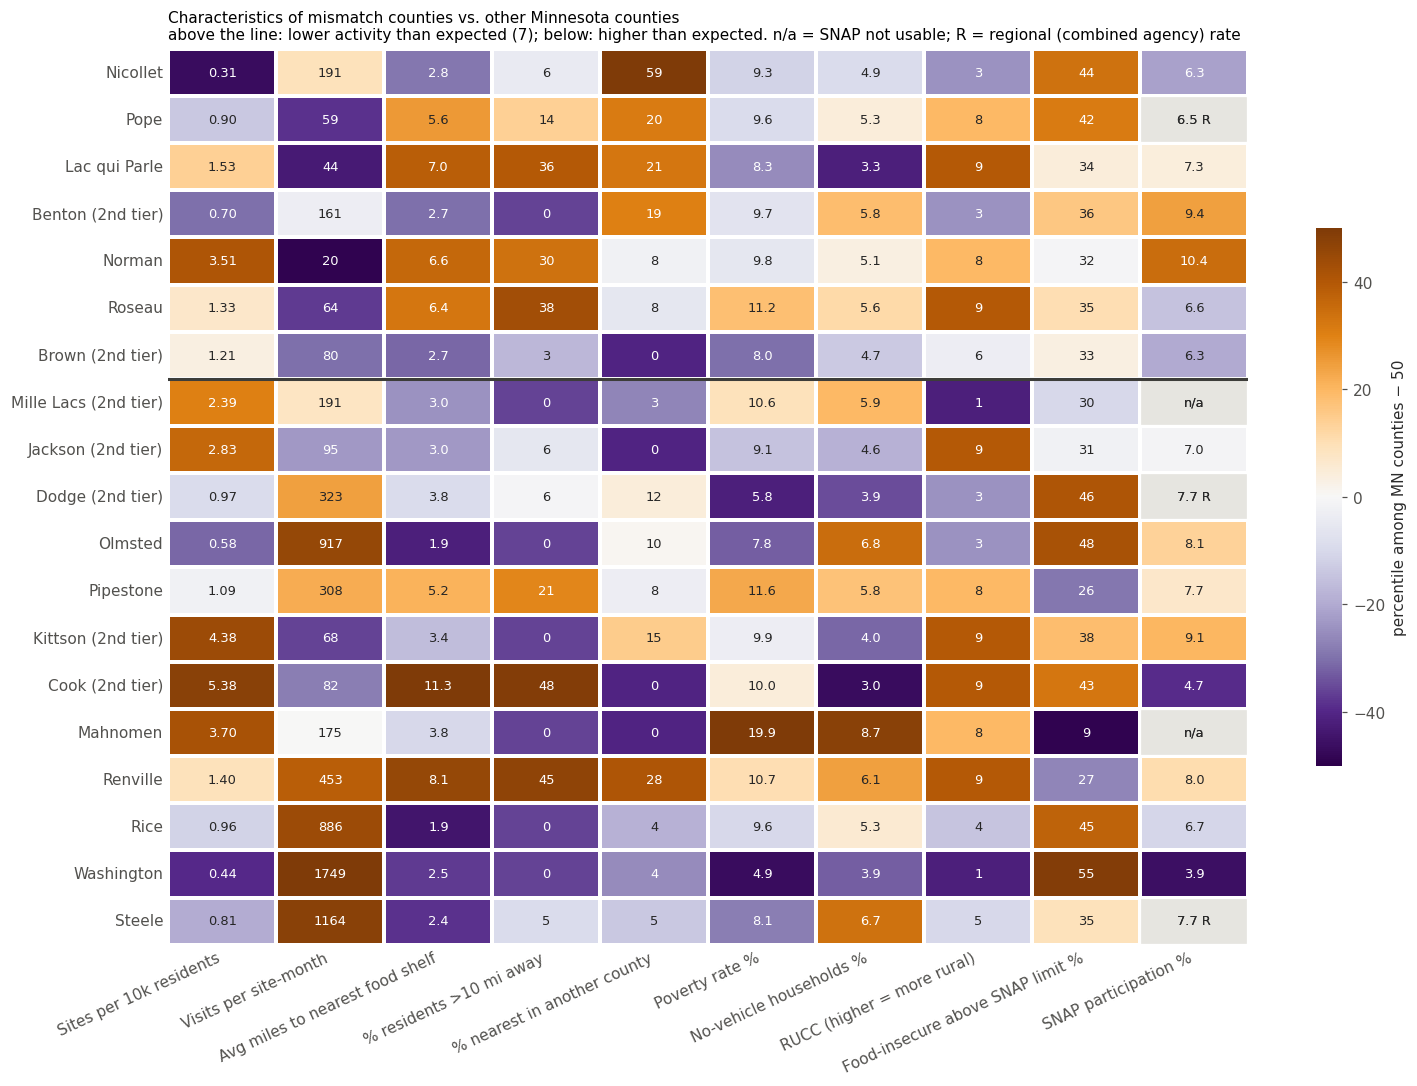

In [50]:
CHAR = {  # column -> short label for tables/plots
    "sites_per_10k": "Sites per 10k residents",
    "visits_per_site_month": "Visits per site-month",
    "mean_dist_mi": "Avg miles to nearest food shelf",
    "pct_over_10mi": "% residents >10 mi away",
    "pct_nearest_other_county": "% nearest in another county",
    "poverty_rate": "Poverty rate %",
    "no_vehicle_rate": "No-vehicle households %",
    "rucc_2023": "RUCC (higher = more rural)",
    "pct_fi_above_snap_threshold": "Food-insecure above SNAP limit %",
    "snap_rate": "SNAP participation %",
}
state_median = prof[list(CHAR)].median()
print("State medians (86 counties):")
print(state_median.round(2).rename(index=CHAR).to_string())

pct = prof[list(CHAR)].rank(pct=True) * 100
focus = prof[prof["priority"].isin(["shortlist", "second tier"])].copy()
focus["order"] = focus["mean_gap_all"]
focus = focus.sort_values("order")
labels = [f"{c}{'' if p == 'shortlist' else ' (2nd tier)'}" for c, p in zip(focus["county"], focus["priority"])]

pct_mat = pct.loc[focus.index, list(CHAR)].set_axis(labels).rename(columns=CHAR)
val_fmt = {"sites_per_10k": "{:.2f}", "visits_per_site_month": "{:.0f}", "mean_dist_mi": "{:.1f}", "pct_over_10mi": "{:.0f}",
           "pct_nearest_other_county": "{:.0f}", "poverty_rate": "{:.1f}",
           "no_vehicle_rate": "{:.1f}", "rucc_2023": "{:.0f}", "pct_fi_above_snap_threshold": "{:.0f}", "snap_rate": "{:.1f}"}
ann = focus[list(CHAR)].apply(lambda col: col.map(lambda v: "n/a" if pd.isna(v) else val_fmt[col.name].format(v)))
for i, (_, r) in enumerate(focus.iterrows()):  # show the regional SNAP rate, marked "R"
    if pd.notna(r["snap_rate_regional"]):
        ann.iloc[i, list(CHAR).index("snap_rate")] = f"{r['snap_rate_regional']:.1f} R"
ann = ann.set_axis(labels).rename(columns=CHAR)

fig, ax = plt.subplots(figsize=(14, 0.42 * len(focus) + 2))
missing = pct_mat.isna()
sns.heatmap((pct_mat - 50).fillna(0), cmap="PuOr_r", center=0, vmin=-50, vmax=50, annot=ann, fmt="", annot_kws={"fontsize": 8.5},
            linewidths=1.5, linecolor="white", cbar_kws={"label": "percentile among MN counties − 50", "shrink": 0.6}, ax=ax)
# Cells without a county-level value (SNAP not usable / regional only): grey, with their label
from matplotlib.patches import Rectangle
for (i, j) in zip(*np.where(missing.to_numpy())):
    ax.add_patch(Rectangle((j, i), 1, 1, facecolor="#e6e5e0", edgecolor="white", lw=1.5))
    ax.text(j + 0.5, i + 0.5, ann.iloc[i, j], ha="center", va="center", fontsize=8.5, color="#2b2b2b")
n_low = int((focus["mean_gap_all"] < 0).sum())
ax.axhline(n_low, color="#3d3d3a", lw=2)
ax.grid(False); ax.tick_params(length=0); ax.set_xlabel(""); ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
ax.set_title("Characteristics of mismatch counties vs. other Minnesota counties\n"
             f"above the line: lower activity than expected ({n_low}); below: higher than expected. "
             "n/a = SNAP not usable; R = regional (combined agency) rate", loc="left", fontsize=10)
plt.tight_layout()
plt.show()

In [51]:
# Vehicle access: is each county's difference from the state median larger than its margin of error?
veh_check = focus[["county", "direction", "no_vehicle_rate", "no_vehicle_rate_moe"]].copy()
veh_check["diff_from_state_median"] = veh_check["no_vehicle_rate"] - state_median["no_vehicle_rate"]
veh_check["clearly_different"] = veh_check["diff_from_state_median"].abs() > veh_check["no_vehicle_rate_moe"]
veh_check.round(2)

,county,direction,no_vehicle_rate,no_vehicle_rate_moe,diff_from_state_median,clearly_different
51,Nicollet,lower than expected,4.89,1.20,-0.21,False
60,Pope,lower than expected,5.30,1.50,0.20,False
36,Lac qui Parle,lower than expected,3.29,1.00,-1.81,True
4,Benton,lower than expected,5.79,1.28,0.70,False
53,Norman,lower than expected,5.14,1.75,0.04,False
67,Roseau,lower than expected,5.62,1.50,0.53,False
7,Brown,lower than expected,4.73,0.96,-0.36,False
47,Mille Lacs,higher than expected,5.92,1.12,0.82,False
31,Jackson,higher than expected,4.58,1.41,-0.52,False
19,Dodge,higher than expected,3.90,1.18,-1.20,True


- **Lower-than-expected counties:** poverty and no-vehicle rates are near the state median (vehicle differences are within the margin of error), so **not a hardship profile**. What stands out is **distance and cross-county access**:
  - **Lac qui Parle, Norman and Roseau:** 30–38% of residents live more than 10 miles from a fixed food shelf.
  - **Nicollet:** 59% of residents' nearest food shelf is in another county.
- **Higher-than-expected counties show two profiles:**
  - **Few but very busy sites with short distances:** Washington, Steele, Rice, Olmsted. Mostly regional centers with low-to-median poverty and many food-insecure people above the SNAP limit.
  - **Many sites for a small population:** Cook, Kittson, Jackson, Mahnomen, Mille Lacs.
- **Mahnomen** has the highest poverty (19.9%) and no-vehicle rate (8.7%), yet records **more** activity than expected.

## 30. Do the mismatch groups differ systematically?

Group medians for counties persistently **lower** than expected (10), **higher** (16) and **no persistent mismatch** (60), with a rank-based **Mann-Whitney** test against the no-mismatch group. With small groups, a non-significant result doesn't prove "no difference", and with many tests one p < 0.05 could appear by chance.

In [52]:
from scipy.stats import mannwhitneyu

GROUPS = ["lower than expected", "no persistent mismatch", "higher than expected"]
group_tbl = prof.groupby("direction")[list(CHAR)].median().reindex(GROUPS).T.rename(index=CHAR)
group_tbl["n (low / none / high)"] = [
    "/".join(str(int(prof.loc[prof["direction"] == g, c].notna().sum())) for g in GROUPS) for c in CHAR]
for g, short in [("lower than expected", "p: low vs none"), ("higher than expected", "p: high vs none")]:
    ps = []
    for c in CHAR:
        a = prof.loc[prof["direction"] == g, c].dropna()
        b = prof.loc[prof["direction"] == "no persistent mismatch", c].dropna()
        ps.append(mannwhitneyu(a, b, alternative="two-sided").pvalue)
    group_tbl[short] = ps
group_tbl.round(3)

direction,lower than expected,no persistent mismatch,higher than expected,n (low / none / high),p: low vs none,p: high vs none
Sites per 10k residents,1.054,1.186,1.247,10/60/16,0.706,0.390
Visits per site-month,94.245,176.829,311.861,10/60/16,0.026,0.076
Avg miles to nearest food shelf,5.630,4.137,3.173,10/60/16,0.287,0.171
% residents >10 mi away,24.808,8.463,2.653,10/60/16,0.042,0.317
% nearest in another county,19.455,11.813,4.810,10/60/16,0.047,0.036
Poverty rate %,9.717,10.000,9.750,10/60/16,0.933,0.296
No-vehicle households %,5.218,5.058,5.547,10/60/16,0.973,0.814
RUCC (higher = more rural),7.500,6.000,6.000,10/60/16,0.171,0.908
Food-insecure above SNAP limit %,33.400,30.867,36.667,10/60/16,0.731,0.154
SNAP participation %,7.272,7.123,6.832,9/53/12,0.795,0.275


In [53]:
print("Rural (RUCC 4-9) share by group:")
rural_tbl = pd.crosstab(prof["direction"], prof["rural"].map({True: "rural", False: "metro"})).reindex(GROUPS)
rural_tbl["% rural"] = (rural_tbl["rural"] / rural_tbl.sum(axis=1) * 100).round(0)
rural_tbl

Rural (RUCC 4-9) share by group:


rural,metro,rural,% rural
direction,,,
lower than expected,2,8,80.0
no persistent mismatch,19,41,68.0
higher than expected,6,10,62.0


- **Access separates the groups most clearly:**
  - **> 10 miles away:** median 25% (lower) vs. 9% (none) vs. 3% (higher); lower vs. none p ≈ 0.04.
  - **Nearest food shelf in another county:** 20% vs. 12% vs. 5%; p ≈ 0.05 (lower) and p ≈ 0.04 (higher).
- **Visits per site-month** also differs (94 vs. 177 vs. 312): lower-than-expected counties have **quiet** sites.
- **Poverty, no-vehicle households and SNAP** have almost identical medians across the groups.
- **Rurality:** the lower group is slightly more rural (80% vs. 68%), but not clearly so.

## 31. Across all counties: is the size of the mismatch associated with each characteristic?

Spearman correlation between each characteristic and every county's continuous mismatch (Part 3 average gap; positive = more activity than expected), overall and per metric.

In [54]:
gap_cols = {"mean_gap_all": "All metrics", "visits_mean_gap": "Visits", "pounds_mean_gap": "Pounds", "individuals_mean_gap": "Individuals"}
assoc_rows = []
for c in CHAR:
    row = {"characteristic": CHAR[c]}
    for gcol, glabel in gap_cols.items():
        sub = prof[[c, gcol]].dropna()
        rho, p = stats.spearmanr(sub[c], sub[gcol])
        row[glabel] = rho
        if gcol == "mean_gap_all":
            row["p (all metrics)"], row["n"] = p, len(sub)
    assoc_rows.append(row)
assoc = pd.DataFrame(assoc_rows).set_index("characteristic")
assoc.round(2)

,All metrics,p (all metrics),n,Visits,Pounds,Individuals
characteristic,,,,,,
Sites per 10k residents,0.25,0.02,86,0.26,0.19,0.23
Visits per site-month,0.23,0.03,86,0.25,0.22,0.25
Avg miles to nearest food shelf,-0.24,0.03,86,-0.24,-0.17,-0.25
% residents >10 mi away,-0.27,0.01,86,-0.25,-0.23,-0.27
% nearest in another county,-0.33,0.00,86,-0.33,-0.29,-0.33
Poverty rate %,-0.16,0.14,86,-0.16,-0.19,-0.14
No-vehicle households %,-0.09,0.40,86,-0.10,-0.12,-0.07
RUCC (higher = more rural),-0.03,0.80,86,-0.05,-0.02,-0.03
Food-insecure above SNAP limit %,0.12,0.26,86,0.10,0.18,0.11


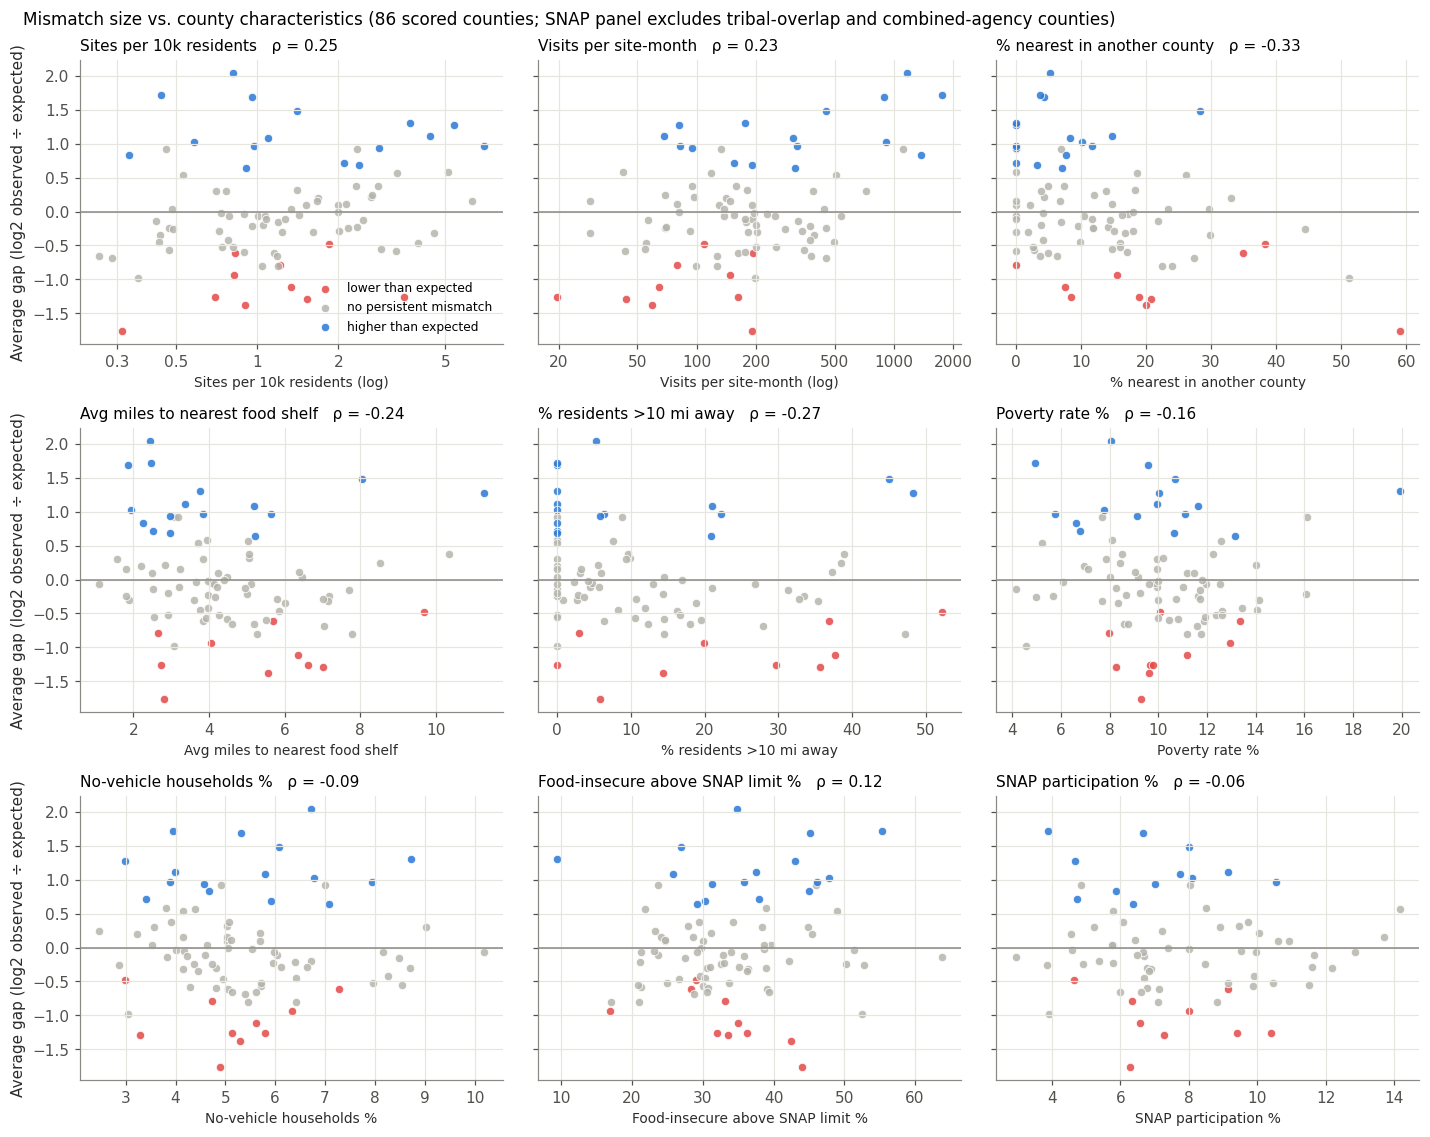

In [55]:
GROUP_COLOR = {"lower than expected": "#e34948", "no persistent mismatch": "#b5b4ac", "higher than expected": "#2a78d6"}
LOG_TICKS = {"sites_per_10k": [0.3, 0.5, 1, 2, 5], "visits_per_site_month": [20, 50, 100, 200, 500, 1000, 2000]}
plot_chars = ["sites_per_10k", "visits_per_site_month", "pct_nearest_other_county",
              "mean_dist_mi", "pct_over_10mi", "poverty_rate",
              "no_vehicle_rate", "pct_fi_above_snap_threshold", "snap_rate"]
fig, axes = plt.subplots(3, 3, figsize=(13, 10.5), sharey=True)
for ax, c in zip(axes.flat, plot_chars):
    for g in GROUPS:
        sub_g = prof[prof["direction"] == g]
        ax.scatter(sub_g[c], sub_g["mean_gap_all"], s=30, color=GROUP_COLOR[g], alpha=0.85, edgecolor="white",
                   linewidth=0.6, label=g)
    ax.axhline(0, color="#8a8984", lw=1)
    if c in LOG_TICKS:
        ax.set_xscale("log")
        ax.set_xticks(LOG_TICKS[c]); ax.set_xticklabels([f"{t:g}" for t in LOG_TICKS[c]]); ax.minorticks_off()
    ax.set_title(f"{CHAR[c]}   ρ = {assoc.loc[CHAR[c], 'All metrics']:.2f}", loc="left", fontsize=10)
    ax.set_xlabel(CHAR[c] + (" (log)" if c in LOG_TICKS else ""), fontsize=9)
for ax in axes[:, 0]:
    ax.set_ylabel("Average gap (log2 observed ÷ expected)")
axes[0, 0].legend(frameon=False, fontsize=8, loc="lower right")
fig.suptitle("Mismatch size vs. county characteristics (86 scored counties; SNAP panel excludes tribal-overlap and combined-agency counties)",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

- **Strongest:** the **share of residents whose nearest food shelf is in another county** (ρ ≈ −0.33, p ≈ 0.002). Where more residents' nearest food shelf lies across the line, the county records less activity than expected.
- **Next:** % over 10 miles (ρ ≈ −0.27) and average distance (ρ ≈ −0.24), both negative (farther → less activity than expected); then site density (+0.25) and visits per site (+0.23).
- **Essentially none:** poverty (−0.16, not significant), no-vehicle households, rurality and SNAP (|ρ| ≤ 0.09).
- **Same pattern for visits, pounds and individuals.** The scatterplots show wide clouds with no hidden curves.

## 32. A simple regression check

One linear regression shows each characteristic's association with the mismatch **while holding the others constant**. Predictors are standardized (coefficient = change in gap per 1 standard deviation): log2 site density, poverty, no-vehicle rate, % food-insecure above the SNAP limit, rural indicator, **% over 10 miles**, **% nearest in another county**. Robust (HC3) standard errors. Average distance is left out because it is almost the same as "% over 10 miles" (ρ ≈ 0.9). SNAP is left out because it would drop 12 counties. Visits per site is left out because it is built from activity.

In [56]:
import statsmodels.formula.api as smf

reg = prof.copy()
reg["log2_sites_per_10k"] = np.log2(reg["sites_per_10k"])
reg["rural_flag"] = reg["rural"].astype(int)
preds = ["log2_sites_per_10k", "poverty_rate", "no_vehicle_rate", "pct_fi_above_snap_threshold",
         "pct_over_10mi", "pct_nearest_other_county"]
for v in preds:
    reg[f"{v}_z"] = (reg[v] - reg[v].mean()) / reg[v].std()

print("Correlation among predictors (Spearman):")
display(reg[preds + ["rural_flag"]].corr(method="spearman").round(2))

model = smf.ols("mean_gap_all ~ log2_sites_per_10k_z + poverty_rate_z + no_vehicle_rate_z"
                " + pct_fi_above_snap_threshold_z + rural_flag + pct_over_10mi_z + pct_nearest_other_county_z", data=reg).fit(cov_type="HC3")
coef_tbl = pd.DataFrame({"coefficient": model.params, "95% low": model.conf_int()[0],
                         "95% high": model.conf_int()[1], "p": model.pvalues}).round(3)
print(f"n = {int(model.nobs)} counties | R² = {model.rsquared:.2f} | adjusted R² = {model.rsquared_adj:.2f}")
coef_tbl

Correlation among predictors (Spearman):


,log2_sites_per_10k,poverty_rate,no_vehicle_rate,pct_fi_above_snap_threshold,pct_over_10mi,pct_nearest_other_county,rural_flag
log2_sites_per_10k,1.00,0.16,-0.14,-0.33,0.19,-0.30,0.38
poverty_rate,0.16,1.00,0.66,-0.66,0.31,-0.15,0.31
no_vehicle_rate,-0.14,0.66,1.00,-0.39,0.04,-0.25,0.04
pct_fi_above_snap_threshold,-0.33,-0.66,-0.39,1.00,-0.42,0.10,-0.56
pct_over_10mi,0.19,0.31,0.04,-0.42,1.00,0.19,0.54
pct_nearest_other_county,-0.30,-0.15,-0.25,0.10,0.19,1.00,-0.11
rural_flag,0.38,0.31,0.04,-0.56,0.54,-0.11,1.00


n = 86 counties | R² = 0.22 | adjusted R² = 0.15


,coefficient,95% low,95% high,p
Intercept,0.044,-0.310,0.398,0.809
log2_sites_per_10k_z,0.152,-0.021,0.324,0.085
poverty_rate_z,0.006,-0.330,0.341,0.974
no_vehicle_rate_z,-0.027,-0.259,0.205,0.822
pct_fi_above_snap_threshold_z,0.161,-0.102,0.424,0.231
rural_flag,-0.064,-0.552,0.425,0.799
pct_over_10mi_z,-0.061,-0.270,0.149,0.570
pct_nearest_other_county_z,-0.264,-0.461,-0.068,0.008


- **The model explains more than before, but still not most:** R² ≈ 0.22 (adjusted ≈ 0.15), up from 0.11 without the access measures.
- **The cross-county share is the only clear predictor** (≈ −0.26 per SD, p ≈ 0.01): about 0.83× expected activity per standard deviation more residents with their nearest food shelf in another county.
- **Site density weakens** (≈ +0.15, not significant). Part of its earlier signal was really about geography.
- **"% over 10 miles" isn't separately significant** once rurality and the cross-county share are included. They overlap (ρ ≈ 0.5 with rural).
- **Poverty, vehicle access and rurality** stay near zero.

## 33. Many sites, or busy sites?

Activity ≈ (number of sites) × (activity per site). For each focus county: is it high because of **many** sites or **busy** sites, or low because of **few** or **quiet** sites?

In [57]:
decomp = focus[["county", "priority", "direction", "times_expected_all", "sites_per_10k", "visits_per_site_month"]].copy()
decomp["sites_per_10k_pctile"] = pct.loc[focus.index, "sites_per_10k"].round(0)
decomp["visits_per_site_pctile"] = pct.loc[focus.index, "visits_per_site_month"].round(0)

def driver(r):
    many, few = r["sites_per_10k_pctile"] >= 60, r["sites_per_10k_pctile"] <= 40
    busy, quiet = r["visits_per_site_pctile"] >= 60, r["visits_per_site_pctile"] <= 40
    if r["direction"] == "higher than expected":
        return "busy sites" if busy and not many else "many sites" if many and not busy else "both" if many and busy else "neither stands out"
    return "few sites" if few and not quiet else "quiet sites" if quiet and not few else "both" if few and quiet else "neither stands out"

decomp["main_driver"] = decomp.apply(driver, axis=1)
print("Percentile >= 60 counts as 'many'/'busy', <= 40 as 'few'/'quiet'.")
decomp.round(2)

Percentile >= 60 counts as 'many'/'busy', <= 40 as 'few'/'quiet'.


,county,priority,direction,times_expected_all,sites_per_10k,visits_per_site_month,sites_per_10k_pctile,visits_per_site_pctile,main_driver
51,Nicollet,shortlist,lower than expected,0.29,0.31,191.19,3.0,59.0,few sites
60,Pope,shortlist,lower than expected,0.39,0.90,59.06,36.0,12.0,both
36,Lac qui Parle,shortlist,lower than expected,0.41,1.53,43.97,64.0,7.0,quiet sites
4,Benton,second tier,lower than expected,0.42,0.70,160.95,20.0,47.0,few sites
53,Norman,shortlist,lower than expected,0.42,3.51,19.60,91.0,1.0,quiet sites
67,Roseau,shortlist,lower than expected,0.46,1.33,64.07,57.0,13.0,quiet sites
7,Brown,second tier,lower than expected,0.58,1.21,79.60,53.0,20.0,quiet sites
47,Mille Lacs,second tier,higher than expected,1.60,2.39,191.17,80.0,58.0,many sites
31,Jackson,second tier,higher than expected,1.91,2.83,94.64,86.0,27.0,many sites
19,Dodge,second tier,higher than expected,1.95,0.97,322.53,41.0,74.0,busy sites


- **Lower than expected:** mostly **quiet sites**, not missing sites (Lac qui Parle, Norman, Roseau, Brown). Only Nicollet and Benton fit "few sites".
- **Higher than expected (shortlist):** mostly **busy sites** (Washington with ~1,750 visits per site-month, Steele, Rice, Olmsted, Renville, Pipestone).
- **Many sites:** the small rural counties (Cook, Kittson, Jackson, Mille Lacs, Mahnomen).

### 33a. Neighbor check: is there evidence of cross-county use?

The data records where food shelves are, not where clients live, so cross-county use **can't be tested directly**. Two indirect checks:
1. The regional center next to each "few sites" county. Nicollet borders **Blue Earth** (Mankato) and Benton borders **Stearns** (St. Cloud); these neighbor pairs are geographic knowledge, not from the data.
2. For every lower-than-expected county, the county where residents' nearest food shelf is located.

In [58]:
pairs = {"Nicollet": "Blue Earth", "Benton": "Stearns"}
nb_rows = []
for county, neighbour in pairs.items():
    for c in (county, neighbour):
        r = prof[prof["county"] == c].iloc[0]
        nb_rows.append({"pair": f"{county} / {neighbour}", "county": c, "direction (Part 3)": r["direction"],
                        "activity vs expected": round(r["times_expected_all"], 2),
                        "sites per 10k": round(r["sites_per_10k"], 2),
                        "visits per site-month": round(r["visits_per_site_month"], 0)})
pd.DataFrame(nb_rows)

,pair,county,direction (Part 3),activity vs expected,sites per 10k,visits per site-month
0,Nicollet / Blue Earth,Nicollet,lower than expected,0.29,0.31,191.0
1,Nicollet / Blue Earth,Blue Earth,no persistent mismatch,1.89,0.46,1113.0
2,Benton / Stearns,Benton,lower than expected,0.42,0.70,161.0
3,Benton / Stearns,Stearns,no persistent mismatch,0.70,0.74,252.0


In [59]:
# For every lower-than-expected county: in which county is each resident's nearest food shelf? (population shares)
rows = []
for _, r in prof[prof["direction"] == "lower than expected"].iterrows():
    b = bg_near[bg_near["fips"] == r["fips"]]
    share = (b.groupby(b["nearest_fips"].map(county_name))["population"].sum() / b["population"].sum() * 100).sort_values(ascending=False)
    others = share.drop(r["county"], errors="ignore")
    rows.append({"county": r["county"], "% nearest in own county": round(share.get(r["county"], 0)),
                 "main other county": others.index[0] if len(others) else "—",
                 "% nearest there": round(others.iloc[0]) if len(others) else 0})
pd.DataFrame(rows).sort_values("% nearest in own county")

,county,% nearest in own county,main other county,% nearest there
5,Nicollet,41,Blue Earth,49
4,Lincoln,62,Yellow Medicine,38
2,Chippewa,65,Yellow Medicine,35
3,Lac qui Parle,79,Chippewa,21
8,Pope,80,Stevens,8
0,Benton,81,Stearns,19
6,Nobles,84,Rock,13
7,Norman,92,Polk,8
9,Roseau,92,Marshall,8
1,Brown,100,—,0


- **Nicollet:** for most residents (about 59%), the nearest food shelf is in **another county**, mainly Blue Earth, which records **1.9× its expected activity** from a few very busy sites. This is the clearest case **consistent with cross-county use**.
- **Benton:** about 19% of residents' nearest food shelf is in Stearns, but Stearns is itself below expected (0.7×), so there's no matching busy neighbor.
- **Lac qui Parle and Pope:** about a fifth of residents' nearest food shelf is in a neighboring county.
- **Lincoln and Chippewa** (low on pounds only): 35–38% of residents' nearest food shelf is in Yellow Medicine.
- **Norman and Roseau:** over 90% have their nearest food shelf in their own county. Their low activity lines up more with **distance** (30–38% live > 10 miles away) than with crossing county lines.

Cross-county use is plausible for some counties, not all. Client ZIP codes from The Food Group would be needed to confirm it.

## 34. Data-quality vs. substantive mismatches

- **A. Likely substantive:** persistent in fully reported years (all shortlisted and second-tier counties).
- **B. Possible data-quality:** low activity coincides with missing reports. These are **not** explained with characteristics.

In [60]:
dq = (mm[["county", "year", "months_reported", "share_site_months_missing", "incomplete"] + [f"{m}_flag" for m in METRICS]
         + [f"{m}_report_concern" for m in METRICS]])
dq_counties = sorted(set(dq.loc[dq[[f"{m}_report_concern" for m in METRICS]].any(axis=1), "county"])
                     | set(per.loc[per["reporting_sensitive"], "county"]))
print("Category B (possible data-quality mismatch):", dq_counties)
display(dq[dq["county"].isin(dq_counties)].round(2))

print("Reporting completeness of the shortlisted / second-tier counties (2022-2024):")
(mm[mm["county"].isin(focus["county"])].groupby("county")
   .agg(min_months_reported=("months_reported", "min"), max_share_site_months_missing=("share_site_months_missing", "max"))
   .round(2).sort_values("max_share_site_months_missing", ascending=False).head(8))

Category B (possible data-quality mismatch): ['Douglas', 'Grant', 'Stevens']


,county,year,months_reported,share_site_months_missing,incomplete,visits_flag,pounds_flag,individuals_flag,visits_report_concern,pounds_report_concern,individuals_report_concern
60,Douglas,2022,12,0.00,False,-1,0,0,False,False,False
61,Douglas,2023,11,0.00,True,-1,0,-1,True,False,True
62,Douglas,2024,12,0.00,False,0,0,0,False,False,False
75,Grant,2022,9,0.61,True,-1,0,-1,True,False,True
76,Grant,2023,12,0.00,False,0,0,0,False,False,False
77,Grant,2024,12,0.00,False,0,0,0,False,False,False
222,Stevens,2022,12,0.00,False,0,0,0,False,False,False
223,Stevens,2023,12,0.00,False,0,0,0,False,False,False
224,Stevens,2024,9,0.25,True,0,-1,0,False,True,False


Reporting completeness of the shortlisted / second-tier counties (2022-2024):


,min_months_reported,max_share_site_months_missing
county,,
Olmsted,12,0.08
Mille Lacs,12,0.06
Jackson,12,0.04
Mahnomen,12,0.04
Norman,12,0.04
Washington,12,0.01
Pipestone,12,0.00
Steele,12,0.00


- **Category B: Douglas, Grant, Stevens.** Each lower-than-expected flag falls in a year with missing reports (Douglas 2023; Grant 2022 with 61% of site-months missing; Stevens 2024).
- **Category A:** every shortlisted and second-tier county reported all 12 months in every year, with at most 8% of site-months missing.

## 35. Final county profiles

One row per shortlisted / second-tier county plus the data-quality cases. "Possible explanation" says what the evidence is **consistent with**. It is a starting point for discussion with The Food Group, not a conclusion.

In [61]:
EXPLANATION = {
    # Lower than expected
    "Nicollet": "Few sites per resident (3rd percentile), and for 59% of residents the nearest food shelf is in another county, mostly Blue Earth (Mankato), which records 1.9x its expected activity. Strongly consistent with residents using food shelves across the county line (not directly testable without client residence). Not explained by poverty or vehicle access.",
    "Pope": "Below-median site density and quiet sites; 14% of residents live more than 10 miles from a food shelf and 20% have their nearest one in another county. Distance and limited availability may partly explain the low head counts. Pounds are closer to expected (0.6-0.7x) than visits.",
    "Lac qui Parle": "36% of residents live more than 10 miles from a fixed food shelf (average 7.0 miles) and 21% have their nearest one in neighboring Chippewa. Distance is a plausible access barrier; poverty and vehicle access are not (both at or below the state median).",
    "Norman": "Many sites per resident but the quietest sites in the state; 30% of residents live more than 10 miles from a fixed food shelf (average 6.6 miles). Distance may contribute. High SNAP participation (10.4%) is consistent with more need being met through SNAP, but SNAP shows no association statewide, so this is weak support.",
    "Roseau": "38% of residents live more than 10 miles from a fixed food shelf (average 6.4 miles), one of the highest shares among the focus counties; remote rural county. Distance is a plausible access barrier; poverty, vehicle access and SNAP are not.",
    "Benton": "Few sites per resident (20th percentile) but short distances (average 2.7 miles); 19% of residents' nearest food shelf is in Stearns (St. Cloud), which is itself below expected, so cross-county use is not clearly supported. Limited local availability remains possible. Second tier: method-dependent.",
    "Brown": "Short distances (average 2.7 miles), typical site density, quiet sites, below-median poverty. No characteristic examined stands out. Second tier (smaller gap).",
    # Higher than expected
    "Steele": "Short distances (average 2.4 miles) and few but very busy sites (98th percentile); activity rising each year. Regional center (Owatonna): consistent with large sites possibly serving people from beyond the county. Not explained by poverty (below median). SNAP available only for the MNPRAIRIE region.",
    "Washington": "All residents within 10 miles of a food shelf; few sites per resident but the busiest sites in Minnesota (~1,750 visits per site-month); lowest poverty and SNAP participation on the shortlist and the highest share of food-insecure people above the SNAP limit (55%). Consistent with food shelves serving SNAP-ineligible food-insecure residents, and with large metro sites possibly drawing from neighboring counties.",
    "Rice": "Short distances (average 1.9 miles), busy sites (94th percentile), 45% of food-insecure people above the SNAP limit. Same busy-site pattern as Washington and Steele; poverty near median.",
    "Olmsted": "Short distances (average 1.9 miles), few but busy sites (95th percentile), metro (Rochester), below-median poverty, 48% of food-insecure people above the SNAP limit. Same busy-regional-site pattern.",
    "Renville": "Busy sites and above-median site density, despite 45% of residents living more than 10 miles from a food shelf and 28% having their nearest one in another county: a counterexample to the distance pattern. No single characteristic stands out.",
    "Mahnomen": "Highest poverty (19.9%) and no-vehicle rate (8.7%) of the focus counties, many sites, all residents within 10 miles (average 3.8 miles), and only 9% of food-insecure people above the SNAP limit. High activity is consistent with very high hardship plus good access, and possibly with MMG understating need here (a hypothesis). SNAP not usable (White Earth Nation agency). Gap narrowed in 2024.",
    "Pipestone": "Above-median poverty (11.6%) with busy sites; 21% of residents live more than 10 miles away. Higher economic hardship could partly explain more activity than the need estimate suggests.",
    "Cook": "Highest site density of the focus counties (98th percentile), although 48% of residents live more than 10 miles from a fixed site (remote county). Consistent with availability. Second tier: method-dependent.",
    "Kittson": "Many sites per resident (94th percentile) and all residents within 10 miles. Consistent with availability. Second tier: method-dependent.",
    "Jackson": "Many sites per resident (86th percentile) and short distances (average 3.0 miles). Consistent with availability. Second tier: method-dependent.",
    "Dodge": "Busy sites, low poverty, 46% of food-insecure people above the SNAP limit; similar to neighboring Steele (same MNPRAIRIE agency). Second tier (smaller gap).",
    "Mille Lacs": "Many sites per resident (80th percentile) and short distances (average 3.0 miles). Consistent with availability. SNAP not usable (Mille Lacs Band agency). Gap faded in 2024. Second tier (smaller gap).",
    # Data-quality cases
    "Douglas": "Possible data-quality case: the lower-than-expected visits partly coincide with an incomplete reporting year (2023). Very low site density (0.26 per 10k), so a real availability effect cannot be ruled out, but it is not interpreted here.",
    "Grant": "Possible data-quality case: low visits and individuals only in 2022, when 61% of site-months were unreported. Not interpreted.",
    "Stevens": "Possible data-quality case: low pounds only in 2024, with 3 months unreported. Not interpreted.",
}

def pattern_text(fips):
    p = per[per["fips"] == fips].set_index("metric")
    parts = [f"{NICE[m]}: {p.loc[m, 'pattern_clean']}" for m in METRICS if p.loc[m, "pattern_clean"] != "not flagged"]
    return "; ".join(parts) if parts else "no persistent flag"

def snap_text(r):
    if pd.notna(r["snap_rate"]):
        return f"{r['snap_rate']:.1f}%"
    if pd.notna(r["snap_rate_regional"]):
        return f"{r['snap_rate_regional']:.1f}% (regional: {r['snap_region'].split(' ')[0]})"
    return "not usable (tribal agency overlap)" if r["snap_status"].startswith("excluded") else "n/a"

prof_focus = prof[prof["priority"].isin(["shortlist", "second tier"]) | prof["county"].isin(dq_counties)].copy()
prof_focus["data_category"] = np.where(prof_focus["county"].isin(dq_counties), "B: possible data-quality", "A: likely substantive")
final_profile = pd.DataFrame({
    "County": prof_focus["county"],
    "Priority": prof_focus["priority"].replace("", "—"),
    "Direction": prof_focus["direction"],
    "Metrics / persistence": prof_focus["fips"].map(pattern_text),
    "Activity vs expected": prof_focus["times_expected_all"].map(lambda v: f"{v:.2f}×"),
    "Poverty %": prof_focus["poverty_rate"].round(1),
    "Metro/rural (RUCC)": prof_focus["rural"].map({True: "rural", False: "metro"}) + " (" + prof_focus["rucc_2023"].astype(int).astype(str) + ")",
    "No-vehicle % (±MOE)": prof_focus["no_vehicle_rate"].map("{:.1f}".format) + " ±" + prof_focus["no_vehicle_rate_moe"].map("{:.1f}".format),
    "Sites per 10k": prof_focus["sites_per_10k"].round(2),
    "Visits per site-month": prof_focus["visits_per_site_month"].round(0),
    "Miles to nearest food shelf": prof_focus["mean_dist_mi"].round(1),
    "% >10 mi away": prof_focus["pct_over_10mi"].round(0),
    "% nearest in another county": prof_focus["pct_nearest_other_county"].round(0),
    "FI above SNAP limit %": prof_focus["pct_fi_above_snap_threshold"].round(0),
    "SNAP participation": prof_focus.apply(snap_text, axis=1),
    "Data category": prof_focus["data_category"],
    "Possible explanation": prof_focus["county"].map(EXPLANATION),
}).sort_values(["Data category", "Priority", "Direction"]).reset_index(drop=True)
print("State medians: poverty {:.1f}% | no-vehicle {:.1f}% | sites/10k {:.2f} | visits/site-month {:.0f} | FI above SNAP limit {:.0f}% | SNAP {:.1f}%"
      .format(*state_median[["poverty_rate", "no_vehicle_rate", "sites_per_10k", "visits_per_site_month",
                             "pct_fi_above_snap_threshold", "snap_rate"]]))
with pd.option_context("display.max_colwidth", 400):
    display(final_profile)

State medians: poverty 10.0% | no-vehicle 5.1% | sites/10k 1.19 | visits/site-month 176 | FI above SNAP limit 33% | SNAP 7.1%


,County,Priority,Direction,Metrics / persistence,Activity vs expected,Poverty %,Metro/rural (RUCC),No-vehicle % (±MOE),Sites per 10k,Visits per site-month,Miles to nearest food shelf,% >10 mi away,% nearest in another county,FI above SNAP limit %,SNAP participation,Data category,Possible explanation
0,Cook,second tier,higher than expected,Visits: persistent high; Pounds: persistent high; Individuals: persistent high,2.41×,10.0,rural (9),3.0 ±1.4,5.38,82.0,11.3,48.0,0.0,43.0,4.7%,A: likely substantive,"Highest site density of the focus counties (98th percentile), although 48% of residents live more than 10 miles from a fixed site (remote county). Consistent with availability. Second tier: method-dependent."
1,Dodge,second tier,higher than expected,Visits: persistent high; Individuals: persistent high,1.95×,5.8,metro (3),3.9 ±1.2,0.97,323.0,3.8,6.0,12.0,46.0,7.7% (regional: MNPRAIRIE),A: likely substantive,"Busy sites, low poverty, 46% of food-insecure people above the SNAP limit; similar to neighboring Steele (same MNPRAIRIE agency). Second tier (smaller gap)."
2,Jackson,second tier,higher than expected,Pounds: persistent high; Individuals: persistent high,1.91×,9.1,rural (9),4.6 ±1.4,2.83,95.0,3.0,6.0,0.0,31.0,7.0%,A: likely substantive,Many sites per resident (86th percentile) and short distances (average 3.0 miles). Consistent with availability. Second tier: method-dependent.
3,Kittson,second tier,higher than expected,Visits: persistent high; Pounds: persistent high; Individuals: persistent high,2.16×,9.9,rural (9),4.0 ±1.8,4.38,68.0,3.4,0.0,15.0,38.0,9.1%,A: likely substantive,Many sites per resident (94th percentile) and all residents within 10 miles. Consistent with availability. Second tier: method-dependent.
4,Mille Lacs,second tier,higher than expected,Visits: persistent high; Individuals: persistent high,1.60×,10.6,metro (1),5.9 ±1.1,2.39,191.0,3.0,0.0,3.0,30.0,not usable (tribal agency overlap),A: likely substantive,Many sites per resident (80th percentile) and short distances (average 3.0 miles). Consistent with availability. SNAP not usable (Mille Lacs Band agency). Gap faded in 2024. Second tier (smaller gap).
5,Benton,second tier,lower than expected,Visits: persistent low; Pounds: persistent low; Individuals: persistent low,0.42×,9.7,metro (3),5.8 ±1.3,0.70,161.0,2.7,0.0,19.0,36.0,9.4%,A: likely substantive,"Few sites per resident (20th percentile) but short distances (average 2.7 miles); 19% of residents' nearest food shelf is in Stearns (St. Cloud), which is itself below expected, so cross-county use is not clearly supported. Limited local availability remains possible. Second tier: method-dependent."
6,Brown,second tier,lower than expected,Visits: persistent low; Individuals: persistent low,0.58×,8.0,rural (6),4.7 ±1.0,1.21,80.0,2.7,3.0,0.0,33.0,6.3%,A: likely substantive,"Short distances (average 2.7 miles), typical site density, quiet sites, below-median poverty. No characteristic examined stands out. Second tier (smaller gap)."
7,Mahnomen,shortlist,higher than expected,Visits: persistent high; Pounds: persistent high; Individuals: persistent high,2.46×,19.9,rural (8),8.7 ±1.4,3.70,175.0,3.8,0.0,0.0,9.0,not usable (tribal agency overlap),A: likely substantive,"Highest poverty (19.9%) and no-vehicle rate (8.7%) of the focus counties, many sites, all residents within 10 miles (average 3.8 miles), and only 9% of food-insecure people above the SNAP limit. High activity is consistent with very high hardship plus good access, and possibly with MMG understating need here (a hypothesis). SNAP not usable (White Earth Nation agency). Gap narrowed in 2024."
8,Olmsted,shortlist,higher than expected,Visits: persistent high; Pounds: one-year high; Individuals: persistent high,2.04×,7.8,metro (3),6.8 ±0.8,0.58,917.0,1.9,0.0,10.0,48.0,8.1%,A: likely substantive,"Short distances (average 1.9 miles), few but busy sites (95th percentile), metro (Rochester), below-median poverty, 48% of food-insecure people above the SNAP limit

### 35a. Save the county profile table

`Data/processed/q1_county_profiles.csv`: one row per county (all 87) with the Part 3 mismatch information, every characteristic above (including the distance measures), SNAP status, data category and possible explanation.

In [62]:
profiles_out = prof.copy()
profiles_out["pattern_by_metric"] = profiles_out["fips"].map(pattern_text)
profiles_out["data_category"] = np.where(profiles_out["county"].isin(dq_counties), "B: possible data-quality",
                                         np.where(profiles_out["direction"] != "no persistent mismatch", "A: likely substantive", ""))
profiles_out["possible_explanation"] = profiles_out["county"].map(EXPLANATION).fillna("")
wilkin_profile = (chars[chars["county"] == "Wilkin"]
                  .assign(direction="not scored (no food shelf in data)", priority="", data_category="", possible_explanation=""))
profiles_out = pd.concat([profiles_out, wilkin_profile], ignore_index=True).sort_values("county")
assert profiles_out["fips"].is_unique and len(profiles_out) == 87
profiles_out.to_csv(PROCESSED / "q1_county_profiles.csv", index=False)
print("q1_county_profiles.csv:", profiles_out.shape)

q1_county_profiles.csv: (87, 34)


## 36. Part 4 summary: what might explain the mismatches?

**Short answer:** no single factor, but **geography and access explain more than hardship does.** The clearest associations involve **where food shelves are relative to where people live**. Poverty, vehicle access, rurality and SNAP participation show little or no association.

**Supported (associations, not causes)**
- **Cross-county access:** the share of residents whose nearest food shelf is in another county is the strongest single factor (ρ ≈ −0.33; regression ≈ −0.26 per SD).
  - **Nicollet** is the clearest case: 59% of residents' nearest food shelf is in another county, mostly Blue Earth, which records 1.9× its expected activity.
- **Distance:** lower-than-expected counties more often have residents far from a fixed food shelf (median 25% beyond 10 miles vs. 9% elsewhere). Lac qui Parle, Norman and Roseau were previously unexplained; 30–38% of their residents live more than 10 miles away.
- **Busy regional sites:** the largest above-expected counties (Washington, Steele, Rice, Olmsted) have short distances and few but very busy sites. Many of their food-insecure residents earn too much for SNAP (45–55%).
- **Site availability:** "many sites for few people" fits the small rural above-expected counties (Cook, Kittson, Jackson, Mille Lacs, Mahnomen).

**Weak or unsupported**
- **Poverty:** nearly identical group medians and no clear association. MMG's model already uses economic indicators.
- **Vehicle access:** no association. Mahnomen has the highest no-vehicle rate and *more* activity than expected.
- **Rurality** on its own and **SNAP participation:** no clear association.

**Exceptions:** Renville is above expected despite long distances, and Mahnomen combines very high hardship with good access. The characteristics together still explain only about **22%** of the variation in mismatches.

**Data quality:** Douglas, Grant and Stevens are possible data-quality cases and are not interpreted.

**Limitations:**
- associations only, with 86 counties;
- straight-line distance;
- no client-residence data, so cross-county use is inferred, not observed;
- SNAP is partial;
- MMG need figures are model estimates.

---

# 37. Question 1: final synthesis

**1. Do Feeding America's estimates and food shelf activity tell the same story?** **Partly.**
- They agree on **size**: counties with more food-insecure people have more visits, pounds and individuals (ρ ≈ 0.9), though this is mostly population.
- They agree on **direction over time**: 2022 → 2024, need +25% vs. visits +46%, individuals +60%.
- They **disagree on intensity**: counties with a higher food insecurity *rate* don't have more food shelf use per resident (ρ ≈ 0 by 2024).

**2. Which metrics track need most closely?** **Pounds** was consistently strongest and **individuals** weakest (visits nearly tied with individuals), but the differences are small and within statistical noise.

**3. Where does the relationship break down?** 12 counties are persistently at least 2× above or ½ below what similar-need counties record:
- **Lower:** Nicollet, Pope, Lac qui Parle, Norman, Roseau.
- **Higher:** Steele, Washington, Rice, Renville, Mahnomen, Pipestone, Olmsted.

**4. What might explain it?** **Geography and access, more than hardship.**
- Counties record **less** activity than expected where residents live **far from a food shelf** or where their **nearest food shelf is across the county line** (Nicollet next to Mankato; Lac qui Parle, Norman and Roseau with 30–38% of residents over 10 miles away).
- Counties record **more** where a few **large regional sites** sit close to residents (Washington, Steele, Rice, Olmsted) or where there are **many sites for few people** (small rural counties).
- Poverty, vehicle access, rurality and SNAP show little association.

**Takeaway for The Food Group:** county need estimates alone are a weak guide to where food shelf activity concentrates. **Where food shelves are, how large they are, and how far people must travel** shape recorded activity at least as much as estimated need. Activity counted where the food shelf sits can make a county look under-served when its residents are being served next door.

**Next steps:**
1. Collect **client ZIP codes** to measure cross-county use directly.
2. Use **driving distance and mobile-pantry routes** for a more realistic access measure.
3. Review recording practices at quiet sites in Lac qui Parle, Norman and Roseau.
4. Plan with **per-resident, site-level and travel-distance** views rather than raw county totals.